# Stochastic Reaction-Diffusion SIR Model under Itô Environmental Noise

**Noise model:** a single one-dimensional Brownian motion $B(t)$ (temporal noise only, spatially uniform).

**Spatial discretization:** Finite differences on $\mathcal{O} = [0, L]$ with **Neumann boundary conditions.**

## Numerical scheme:**
- PDE drift: explicit Euler in time, second-order central differences in space
- Stochastic term: Euler–Maruyama (consistent with Itô interpretation)
- Time step $dt$ and mesh size $dx$ chosen to satisfy CFL condition $D \cdot dt / dx^2 \leq 0.5$


| Component | Method |
|-----------|--------|
| ODE | RK45 (SciPy `solve_ivp`), `rtol=1e-9` |
| PDE / SPDE drift | Explicit Euler in time |
| PDE / SPDE diffusion | Implicit (backward-Euler tridiagonal, Crank–Nicolson-like) |
| SPDE noise | Euler–Maruyama: $\Delta W_k = \sqrt{dt}\,Z_k$, $Z_k\sim\mathcal{N}(0,1)$ i.i.d. |
| Spatial discretisation | Second-order central finite differences |
| Stability condition | CFL: $D\,dt/dx^2 \le 0.5$ |

Recall that
$$\mathcal{R}_0^D = \frac{\beta}{\alpha + \gamma + \mu + \delta} = \frac{\beta}{m}, \qquad \mathcal{R}_0^S = \frac{\beta}{\alpha + \gamma + \mu + \delta + \frac{\sigma^2}{2}} = \frac{\beta}{m+ \frac{\sigma^2}{2}}.$$

## 1. Deterministic SIR model
$$\begin{cases}
\dot{S} = \Lambda - \beta \frac{SI}{N} + \alpha I - \mu S \\
\dot{I} = \beta \frac{SI}{N} - mI \\
\dot{R} = \gamma I - \mu R
\end{cases}$$

where $m=\alpha+\gamma+\mu+\delta$, $N=S+I+R$. 

For this ODE deterministic system, the disease-free equilibrium is $E_0 = (S^0, 0, 0)^\top$, with $S^0=\Lambda/\mu$, and the endemic equilibrium is:
$$E^* = \left(S^* = \frac{\Lambda(\mu+\gamma)}{\mu\Big[(\gamma+\delta)\mathcal R_0^D+\mu-\delta\Big]},\;
I^* = \frac{\Lambda(\mathcal R_0^D-1)}{(\gamma+\delta)\mathcal R_0^D+\mu-\delta},\;
R^* = \frac{\gamma\Lambda(\mathcal R_0^D-1)}{\mu\Big[(\gamma+\delta)\mathcal R_0^D+\mu-\delta\Big]}\right)$$

## 2. Partial deterministic model
$$\begin{cases}
\partial_t S = D\Delta S + \Lambda(x) - \beta(x)\frac{SI}{N} + \alpha(x)I - \mu(x)S \\
\partial_t I = D\Delta I + \beta(x)\frac{SI}{N} - m(x)I \\
\partial_t R = D\Delta R + \gamma(x)I - \mu(x)R
\end{cases}$$

## 3. Stochastic reaction-diffusion model
$$\begin{cases}
dS = \left[\Lambda - \beta\frac{SI}{N} + \alpha I - \mu S\right]dt + \sigma S\,dB(t)\\
dI = \left[\beta\frac{SI}{N} - m\,I\right]dt + \sigma I\,dB(t)\\
dR = \left[\gamma I - \mu R\right]dt + \sigma R\,dB(t)
\end{cases}$$

**Scheme:** Euler–Maruyama with $\Delta W_k = \sqrt{dt}\,Z_k$, $Z_k \sim \mathcal{N}(0,1)$ i.i.d.

The spatially-varying parameters satisfy $\overline{\Lambda(x)}=\Lambda$, $\overline{\beta(x)}=\beta$, $\overline{\gamma(x)}=\gamma$, $\overline{\mu(x)}=\mu$ (spatial means equal the ODE values), ensuring a fair ODE–PDE comparison.

## Parameters and initial conditions

All simulations share the same initial conditions $S(0)=S_0$, $I(0)=I_0$, $R(0)=0$.  
For ODE and SDE: $(S_0,I_0)=(490,10)$.  
For PDE and SPDE: $S(0,x)=S_0$, $I(0,x)=I_0$ (spatially **uniform**, identical to ODE/SDE values).

| Parameter | Symbol | Value |
|-----------|--------|-------|
| Recruitment | $\Lambda$ | 10 |
| Transmission (Scenario A) | $\beta$ | 0.30 |
| Transmission (Scenario B) | $\beta$ | 0.05 |
| Recovery | $\gamma$ | 0.10 |
| Return-to-S | $\alpha$ | 0.05 |
| Disease mortality | $\delta$ | 0.01 |
| Natural mortality | $\mu$ | 0.02 |
| Diffusion | $D$ | 0.10 |
| Domain length | $L$ | 10 |
| Spatial nodes | $N_x$ | 100 |
| Noise (Scenario A) | $\sigma$ | 0.05 |
| Noise (Scenario B) | $\sigma$ | 0.60 |
| EM time step | $dt_s$ | 0.0005 |


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import solve_banded
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

import random

np.random.seed(42)
random.seed(42)

In [ ]:
plt.rcParams.update({
    "figure.dpi": 150, "font.family": "serif", "font.size": 11,
    "axes.labelsize": 12, "axes.titlesize": 12, "legend.fontsize": 9,
    "lines.linewidth": 2, "axes.grid": True, "grid.alpha": 0.3,
})

# Parameters
Lambda_p = 10.0
beta_p   = 0.30      # Scenario A: R0_D > 1
beta_B   = 0.05      # Scenario B: R0_D < 1
gamma_p  = 0.10
alpha_p  = 0.05
delta_p  = 0.01
mu_p     = 0.02
m_p      = alpha_p + gamma_p + mu_p + delta_p   # = 0.18

S0_val, I0_val = 490.0, 10.0   # same initial conditions for ODE, SDE, PDE, SPDE

In [ ]:
# Reproduction numbers
R0_D  = beta_p / m_p
R0_B  = beta_B / m_p

sigma_A = 0.05
sigma_B = 0.60
R0S_A   = beta_p / (m_p + sigma_A**2 / 2)
R0S_B   = beta_p / (m_p + sigma_B**2 / 2)   # < 1

# DFE and endemic equilibrium
S0_dfe = Lambda_p / mu_p
D_eq   = (gamma_p + delta_p) * R0_D + mu_p - delta_p
S_star = Lambda_p * (mu_p + gamma_p) / (mu_p * D_eq)
I_star = Lambda_p * (R0_D - 1) / D_eq
R_star = gamma_p * Lambda_p * (R0_D - 1) / (mu_p * D_eq)

print("═"*60)
print(f"  m        = {m_p:.4f}")
print(f"  S0_dfe   = {S0_dfe:.2f}")
print(f"  R0_D (A) = {R0_D:.4f}  > 1  impliies Endemic")
print(f"  R0_D (B) = {R0_B:.4f}  < 1  impliies Extinction")
print(f"  R0S_A    = {R0S_A:.4f}  > 1 impliies Persistence")
print(f"  R0S_B    = {R0S_B:.4f}  < 1 impliies Extinction")
print(f"  E*       = (S={S_star:.2f}, I={I_star:.2f}, R={R_star:.2f})")
print(f"  IC       = (S0={S0_val}, I0={I0_val}, R0=0)")
print("═"*60)

════════════════════════════════════════════════════════════
  m        = 0.1800
  S0_dfe   = 500.00
  R0_D (A) = 1.6667  > 1  ->  Endemic
  R0_D (B) = 0.2778  < 1  ->  Extinction
  R0S_A    = 1.6552  > 1  ->  Persistence
  R0S_B    = 0.8333  < 1  ->  Extinction
  E*       = (S=310.34, I=34.48, R=172.41)
  IC       = (S0=490.0, I0=10.0, R0=0)
════════════════════════════════════════════════════════════


In [2]:
# Spatial grid 
L    = 10.0
Nx   = 100
dx   = L / (Nx - 1)
x    = np.linspace(0, L, Nx)
D_diff = 0.10
dt_pde = 0.4 * dx**2 / D_diff    # CFL < 0.5 (safety margin)
T_pde  = 200.0
Nt_pde = int(T_pde / dt_pde)
thin   = max(1, Nt_pde // 400)  #400 snapshotss

print(f"Grid: Nx={Nx}, dx={dx:.4f}, dt_pde={dt_pde:.6f}, T_pde={T_pde}, Nt={Nt_pde}")
print(f"CFL number: {D_diff*dt_pde/dx**2:.4f}  (must be ≤ 0.5)")
print(f"Snapshots stored: {Nt_pde // thin}")

# Spatially heterogeneous parameters 
Lambda_x = Lambda_p * (1.0 + 0.2 * np.sin(2*np.pi*x/L))   
beta_x   = beta_p   * (1.0 + 0.3 * np.sin(2*np.pi*x/L))   
beta_x_B = beta_B   * (1.0 + 0.3 * np.sin(2*np.pi*x/L))   
alpha_x  = alpha_p  * np.ones(Nx)
gamma_x  = gamma_p  * np.ones(Nx)
mu_x     = mu_p     * np.ones(Nx)
m_x      = alpha_x + gamma_x + mu_x + delta_p

# Verify means
assert abs(Lambda_x.mean() - Lambda_p) < 1e-10, "Lambda mean wrong"
assert abs(beta_x.mean()   - beta_p)   < 1e-10, "beta mean wrong"
print(f"Spatial means verified: Lambda_x.mean={Lambda_x.mean():.4f}, beta_x.mean={beta_x.mean():.4f}")

# Implicit diffusion operator (tridiagonal, Neumann BCs)
r    = D_diff * dt_pde / dx**2
diag = (1 + 2*r) * np.ones(Nx)
off  = -r * np.ones(Nx - 1)
diag[0]  -= r    
diag[-1] -= r   
ab = np.zeros((3, Nx))
ab[0, 1:]  = off
ab[1, :]   = diag
ab[2, :-1] = off

def implicit_diffuse(u):
    return solve_banded((1, 1), ab, u)

# Uniform initial conditions (same as ODE/SDE) 
S_ic = S0_val * np.ones(Nx)
I_ic = I0_val * np.ones(Nx)
R_ic = np.zeros(Nx)
print(f"PDE/SPDE IC: S(0,x)={S0_val}, I(0,x)={I0_val}, R(0,x)=0")

Grid: Nx=100, dx=0.1010, dt_pde=0.040812, T_pde=200.0, Nt=4900
CFL number: 0.4000  (must be ≤ 0.5)
Snapshots stored: 408
Spatial means verified: Lambda_x.mean=10.0000, beta_x.mean=0.3000
PDE/SPDE IC: S(0,x)=490.0, I(0,x)=10.0, R(0,x)=0  (uniform, = ODE IC)


In [3]:
def sir_ode(t, y, Lam, bet, gam, alp, dlt, mu):
    S, I, R = y
    N = max(S + I + R, 1e-12)
    return [
        Lam - bet*S*I/N + alp*I - mu*S,
        bet*S*I/N - (alp+gam+mu+dlt)*I,
        gam*I - mu*R,
    ]

_pA = (Lambda_p, beta_p, gamma_p, alpha_p, delta_p, mu_p)
_pB = (Lambda_p, beta_B, gamma_p, alpha_p, delta_p, mu_p)

def solve_sir(S0, I0, R0i, params=_pA, t_end=300, n=6001):
    sol = solve_ivp(sir_ode, (0, t_end), [S0, I0, R0i], args=params,
                    t_eval=np.linspace(0, t_end, n),
                    method='RK45', rtol=1e-10, atol=1e-12)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

ODE solver ready.


In [4]:
def run_det_pde(S0, I0, R0, beta_x_loc, T_end=T_pde):
    # Deterministic reaction-diffusion PDE 
    S = S0 * np.ones(Nx)
    I = I0 * np.ones(Nx)
    R = R0 * np.zeros(Nx)
    Nt_loc = int(T_end / dt_pde)
    th = max(1, Nt_loc // 400)
    t_out = [0.0]; S_out = [S.copy()]; I_out = [I.copy()]; R_out = [R.copy()]
    for k in range(1, Nt_loc + 1):
        N_ = np.maximum(S + I + R, 1e-12)
        fS = Lambda_x - beta_x_loc*S*I/N_ + alpha_x*I - mu_x*S
        fI = beta_x_loc*S*I/N_ - m_x*I
        fR = gamma_x*I - mu_x*R
        S = np.maximum(implicit_diffuse(S + dt_pde*fS), 0.0)
        I = np.maximum(implicit_diffuse(I + dt_pde*fI), 0.0)
        R = np.maximum(implicit_diffuse(R + dt_pde*fR), 0.0)
        if k % th == 0:
            t_out.append(k*dt_pde)
            S_out.append(S.copy()); I_out.append(I.copy()); R_out.append(R.copy())
    return np.array(t_out), np.array(S_out), np.array(I_out), np.array(R_out)

print("Running Det. PDE - Scenario A (R0>1)...")
t_pA, S_pA, I_pA, R_pA = run_det_pde(S0_val, I0_val, 0, beta_x)
print(f"  Done: {t_pA.shape[0]} snapshots, t_end={t_pA[-1]:.1f}")

print("Running Det. PDE - Scenario B (R0<1)...")
t_pB, S_pB, I_pB, R_pB = run_det_pde(S0_val, I0_val, 0, beta_x_B)
print(f"  Done: {t_pB.shape[0]} snapshots, t_end={t_pB[-1]:.1f}")

Running Det. PDE - Scenario A (R0>1)...
  Done: 409 snapshots, t_end=199.8
Running Det. PDE - Scenario B (R0<1)...
  Done: 409 snapshots, t_end=199.8


  Done: 409 snapshots, t_end=199.8


In [5]:
dt_s  = 0.0005          # fine EM step for stability
T_sde = 200.0

def run_sde(sigma, beta_val, T_end=T_sde, seed=None):
    # Euler-Maruyama SDE - same IC as ODE.
    rng  = np.random.default_rng(seed)
    S, I, R = S0_val, I0_val, 0.0
    sqdt = np.sqrt(dt_s)
    Nt   = int(T_end / dt_s)
    th   = max(1, Nt // 3000)
    rec  = [(0.0, S, I, R)]
    for k in range(1, Nt + 1):
        N_ = max(S + I + R, 1e-12)
        fS = Lambda_p - beta_val*S*I/N_ + alpha_p*I - mu_p*S
        fI = beta_val*S*I/N_ - m_p*I
        fR = gamma_p*I - mu_p*R
        dW = sqdt * rng.standard_normal()
        S  = max(S + dt_s*fS + sigma*S*dW, 0.0)
        I  = max(I + dt_s*fI + sigma*I*dW, 0.0)
        R  = max(R + dt_s*fR + sigma*R*dW, 0.0)
        if k % th == 0:
            rec.append((k*dt_s, S, I, R))
    arr = np.array(rec)
    return arr[:,0], arr[:,1], arr[:,2], arr[:,3]

print(f"SDE: dt_s={dt_s}, T_sde={T_sde}")
print("Running SDE - Scenario A...")
t_sA, S_sA, I_sA, R_sA = run_sde(sigma_A, beta_p,  seed=42)
print("Running SDE - Scenario B...")
t_sB, S_sB, I_sB, R_sB = run_sde(sigma_B, beta_B, seed=42)

SDE: dt_s=0.0005, T_sde=200.0
Running SDE - Scenario A...
Running SDE - Scenario B...
Done.


Done.


In [6]:
n_paths = 10

def run_spde(sigma, beta_x_loc, T_end=T_pde, seed=None):
    # SPDE: reaction-diffusion + temporal Brownian noise B(t).
    rng  = np.random.default_rng(seed)
    sqdt = np.sqrt(dt_pde)
    S = S_ic.copy(); I = I_ic.copy(); R = R_ic.copy()
    Nt_loc = int(T_end / dt_pde)
    th = max(1, Nt_loc // 400)
    t_out = [0.0]; S_out = [S.copy()]; I_out = [I.copy()]; R_out = [R.copy()]
    for k in range(1, Nt_loc + 1):
        dW = sqdt * rng.standard_normal()   # single scalar - temporal noise B(t)
        N_ = np.maximum(S + I + R, 1e-12)
        fS = Lambda_x - beta_x_loc*S*I/N_ + alpha_x*I - mu_x*S
        fI = beta_x_loc*S*I/N_ - m_x*I
        fR = gamma_x*I - mu_x*R
        S = np.maximum(implicit_diffuse(S + dt_pde*fS + sigma*S*dW), 0.0)
        I = np.maximum(implicit_diffuse(I + dt_pde*fI + sigma*I*dW), 0.0)
        R = np.maximum(implicit_diffuse(R + dt_pde*fR + sigma*R*dW), 0.0)
        if k % th == 0:
            t_out.append(k*dt_pde)
            S_out.append(S.copy()); I_out.append(I.copy()); R_out.append(R.copy())
    return np.array(t_out), np.array(S_out), np.array(I_out), np.array(R_out)

print(f"SPDE: dt_pde={dt_pde:.6f}, n_paths={n_paths}")
print("Running SPDE - Scenario A (sigma=0.05)...")
spde_A = [run_spde(sigma_A, beta_x,   seed=k)     for k in range(n_paths)]
print("Running SPDE - Scenario B (sigma=0.60)...")
spde_B = [run_spde(sigma_B, beta_x_B, seed=k+100) for k in range(n_paths)]

def spde_smean(paths, comp):
    # Spatial mean of component comp (1=S,2=I,3=R) across all paths
    return np.array([p[comp].mean(axis=1) for p in paths])

SPDE: dt_pde=0.040812, n_paths=10
Running SPDE - Scenario A (sigma=0.05)...
Running SPDE - Scenario B (sigma=0.60)...
Done.


Done.


## a) Deterministic ODE - Time Series and Phase Portraits

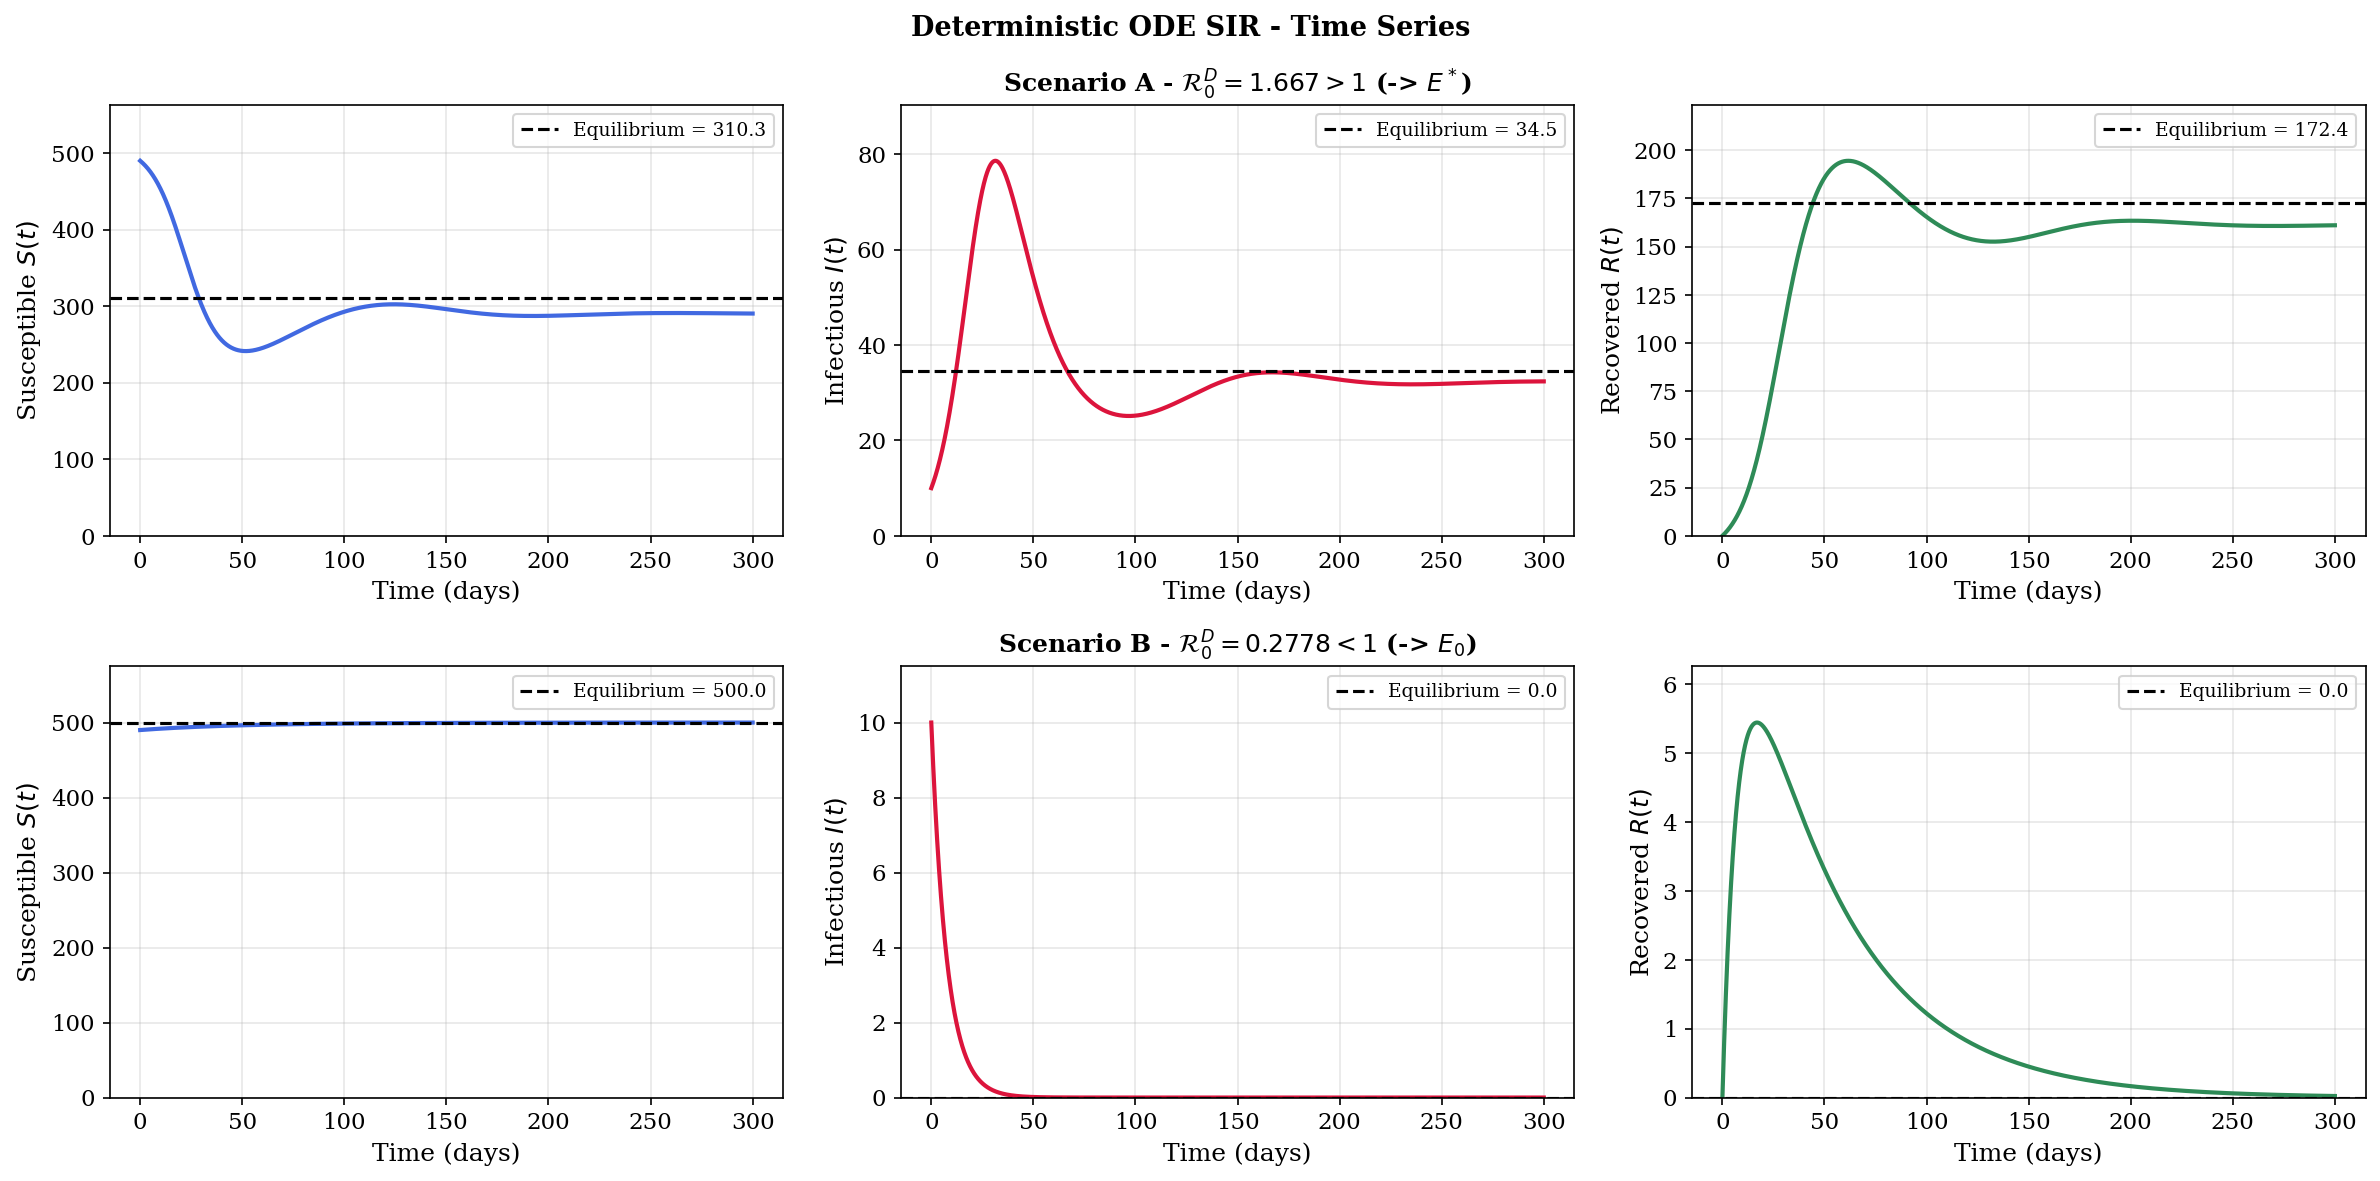

Fig 1 OK - IC: S0=490.0, I0=10.0, R0=0  |  Parameters: Lambda=10.0, beta_A=0.3, beta_B=0.05, gamma=0.1, alpha=0.05, delta=0.01, mu=0.02


In [7]:
T_ode = 300.0
t_oA, S_oA, I_oA, R_oA = solve_sir(S0_val, I0_val, 0, params=_pA, t_end=T_ode)
t_oB, S_oB, I_oB, R_oB = solve_sir(S0_val, I0_val, 0, params=_pB, t_end=T_ode)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Deterministic ODE SIR - Time Series", fontsize=13, fontweight='bold')

for col, (comp_A, comp_B, lbl, col_, eq_A, eq_B) in enumerate(zip(
        [S_oA, I_oA, R_oA], [S_oB, I_oB, R_oB],
        ['Susceptible $S(t)$', 'Infectious $I(t)$', 'Recovered $R(t)$'],
        ['royalblue', 'crimson', 'seagreen'],
        [S_star, I_star, R_star], [S0_dfe, 0.0, 0.0])):

    for row, (t_, comp, eq_val, title) in enumerate([
            (t_oA, comp_A, eq_A,
             fr"Scenario A - $\mathcal{{R}}_0^D={R0_D:.3f}>1$ (-> $E^*$)"),
            (t_oB, comp_B, [S0_dfe, 0.0, 0.0][col],
             fr"Scenario B - $\mathcal{{R}}_0^D={R0_B:.4f}<1$ (-> $E_0$)")]):
        ax = axes[row, col]
        ax.plot(t_, comp, color=col_, lw=2)
        ax.axhline(eq_val, color='black', ls='--', lw=1.5,
                   label=f'Equilibrium = {eq_val:.1f}')
        ax.set_xlabel('Time (days)'); ax.set_ylabel(lbl)
        y_top = max(comp.max(), eq_val) * 1.15
        ax.set_ylim(0, max(y_top, 1.0))
        ax.legend(fontsize=9)
        if col == 1: ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_ODE_timeseries.png', bbox_inches='tight')
plt.show()
print("  ")
print("IC: S0={}, I0={}, R0=0  |  Parameters: Lambda={}, beta_A={}, beta_B={}, gamma={}, alpha={}, delta={}, mu={}".format(
    S0_val, I0_val, Lambda_p, beta_p, beta_B, gamma_p, alpha_p, delta_p, mu_p))


### Phase Portraits (multiple initial conditions)

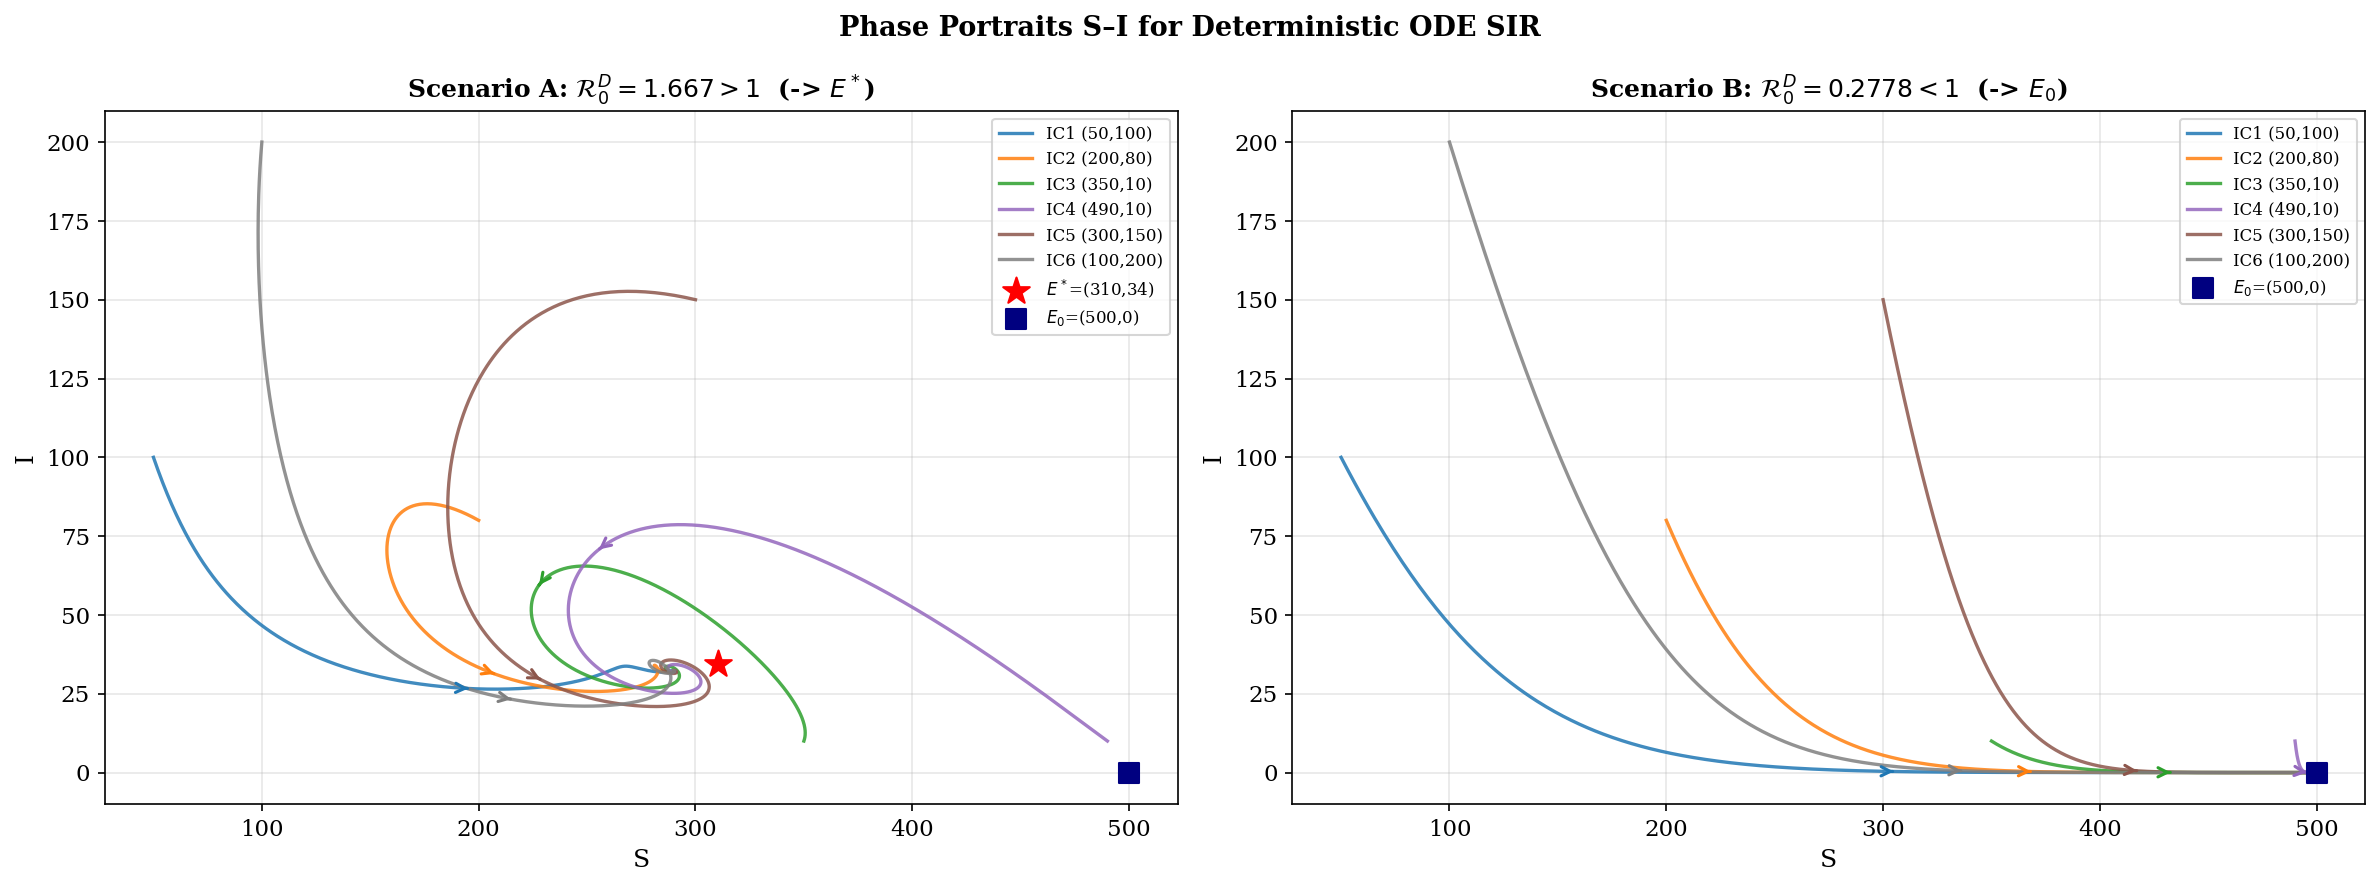

Fig 2 OK


In [8]:
ICs = [(50,100,0),(200,80,0),(350,10,0),(490,10,0),(300,150,0),(100,200,0)]
cols_traj = plt.cm.tab10(np.linspace(0,0.7,len(ICs)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Phase Portraits S–I for Deterministic ODE SIR", fontsize=13, fontweight='bold')

for ax, bval, R0v, title, draw_star in zip(
        axes,
        [beta_p, beta_B],
        [R0_D, R0_B],
        [fr"Scenario A: $\mathcal{{R}}_0^D={R0_D:.3f}>1$  (-> $E^*$)",
         fr"Scenario B: $\mathcal{{R}}_0^D={R0_B:.4f}<1$  (-> $E_0$)"],
        [True, False]):
    for k,(s0,i0,r0_) in enumerate(ICs):
        _,S_,I_,_ = solve_sir(s0,i0,r0_,
            params=(Lambda_p,bval,gamma_p,alpha_p,delta_p,mu_p), t_end=800)
        ax.plot(S_,I_, color=cols_traj[k], alpha=0.85, lw=1.6,
                label=f'IC{k+1} ({s0},{i0})')
        j = max(1, len(S_)//20)
        ax.annotate('', xy=(S_[j],I_[j]), xytext=(S_[j-1],I_[j-1]),
                    arrowprops=dict(arrowstyle='->', color=cols_traj[k], lw=1.5))
    if draw_star:
        ax.scatter(S_star, I_star, color='red', s=180, marker='*', zorder=6,
                   label=f'$E^*$=({S_star:.0f},{I_star:.0f})')
    ax.scatter(S0_dfe, 0, color='navy', s=100, marker='s', zorder=6,
               label=f'$E_0$=({S0_dfe:.0f},0)')
    ax.set_xlabel('S'); ax.set_ylabel('I')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig2_phase2D.png', bbox_inches='tight')
plt.show()

### Sensitivity Heatmap of $\mathcal{R}_0^D$

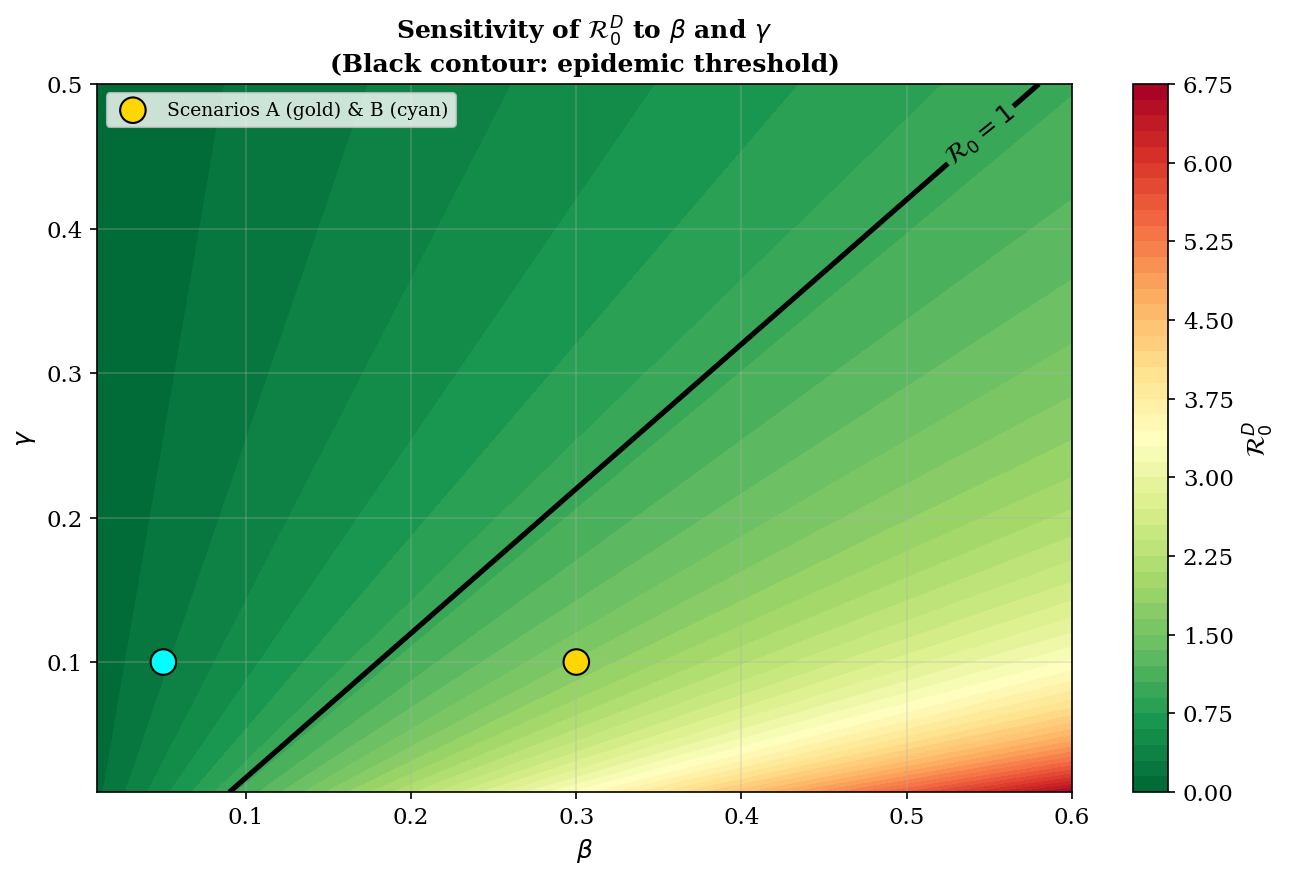

Fig 3 OK


In [9]:
beta_g  = np.linspace(0.01, 0.6, 300)
gamma_g = np.linspace(0.01, 0.5, 300)
B_g, G_g = np.meshgrid(beta_g, gamma_g)
R0_g = B_g / (alpha_p + G_g + mu_p + delta_p)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(beta_g, gamma_g, R0_g, levels=50, cmap='RdYlGn_r')
cs = ax.contour(beta_g, gamma_g, R0_g, levels=[1.0], colors='black', linewidths=2.5)
ax.clabel(cs, fmt={1.0: r'$\mathcal{R}_0=1$'}, fontsize=12)
plt.colorbar(cf, ax=ax, label=r'$\mathcal{R}_0^D$')
ax.scatter([beta_p, beta_B], [gamma_p, gamma_p],
           color=['gold','cyan'], edgecolors='black', s=150, zorder=5,
           label='Scenarios A (gold) & B (cyan)')
ax.set_xlabel(r'Transmission rate $\beta$'); ax.set_ylabel(r'Recovery rate $\gamma$')
ax.set_title(r"Sensitivity of $\mathcal{R}_0^D$ to $\beta$ and $\gamma$"
             "\n(Black contour: epidemic threshold $\\mathcal{R}_0^D=1$)", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_R0_heatmap.png', bbox_inches='tight')
plt.show()

## b) Deterministic ODE vs Deterministic PDE

**Same initial conditions:** $S(0)=S(0,x)=490$, $I(0)=I(0,x)=10$.  
**Spatial means** of PDE parameters equal ODE parameters exactly.  
**Same time step** used for both PDE scenarios.  
The PDE curve shown is the **spatial mean** $\overline{u}(t)=\frac{1}{L}\int_0^L u(t,x)\,dx$.


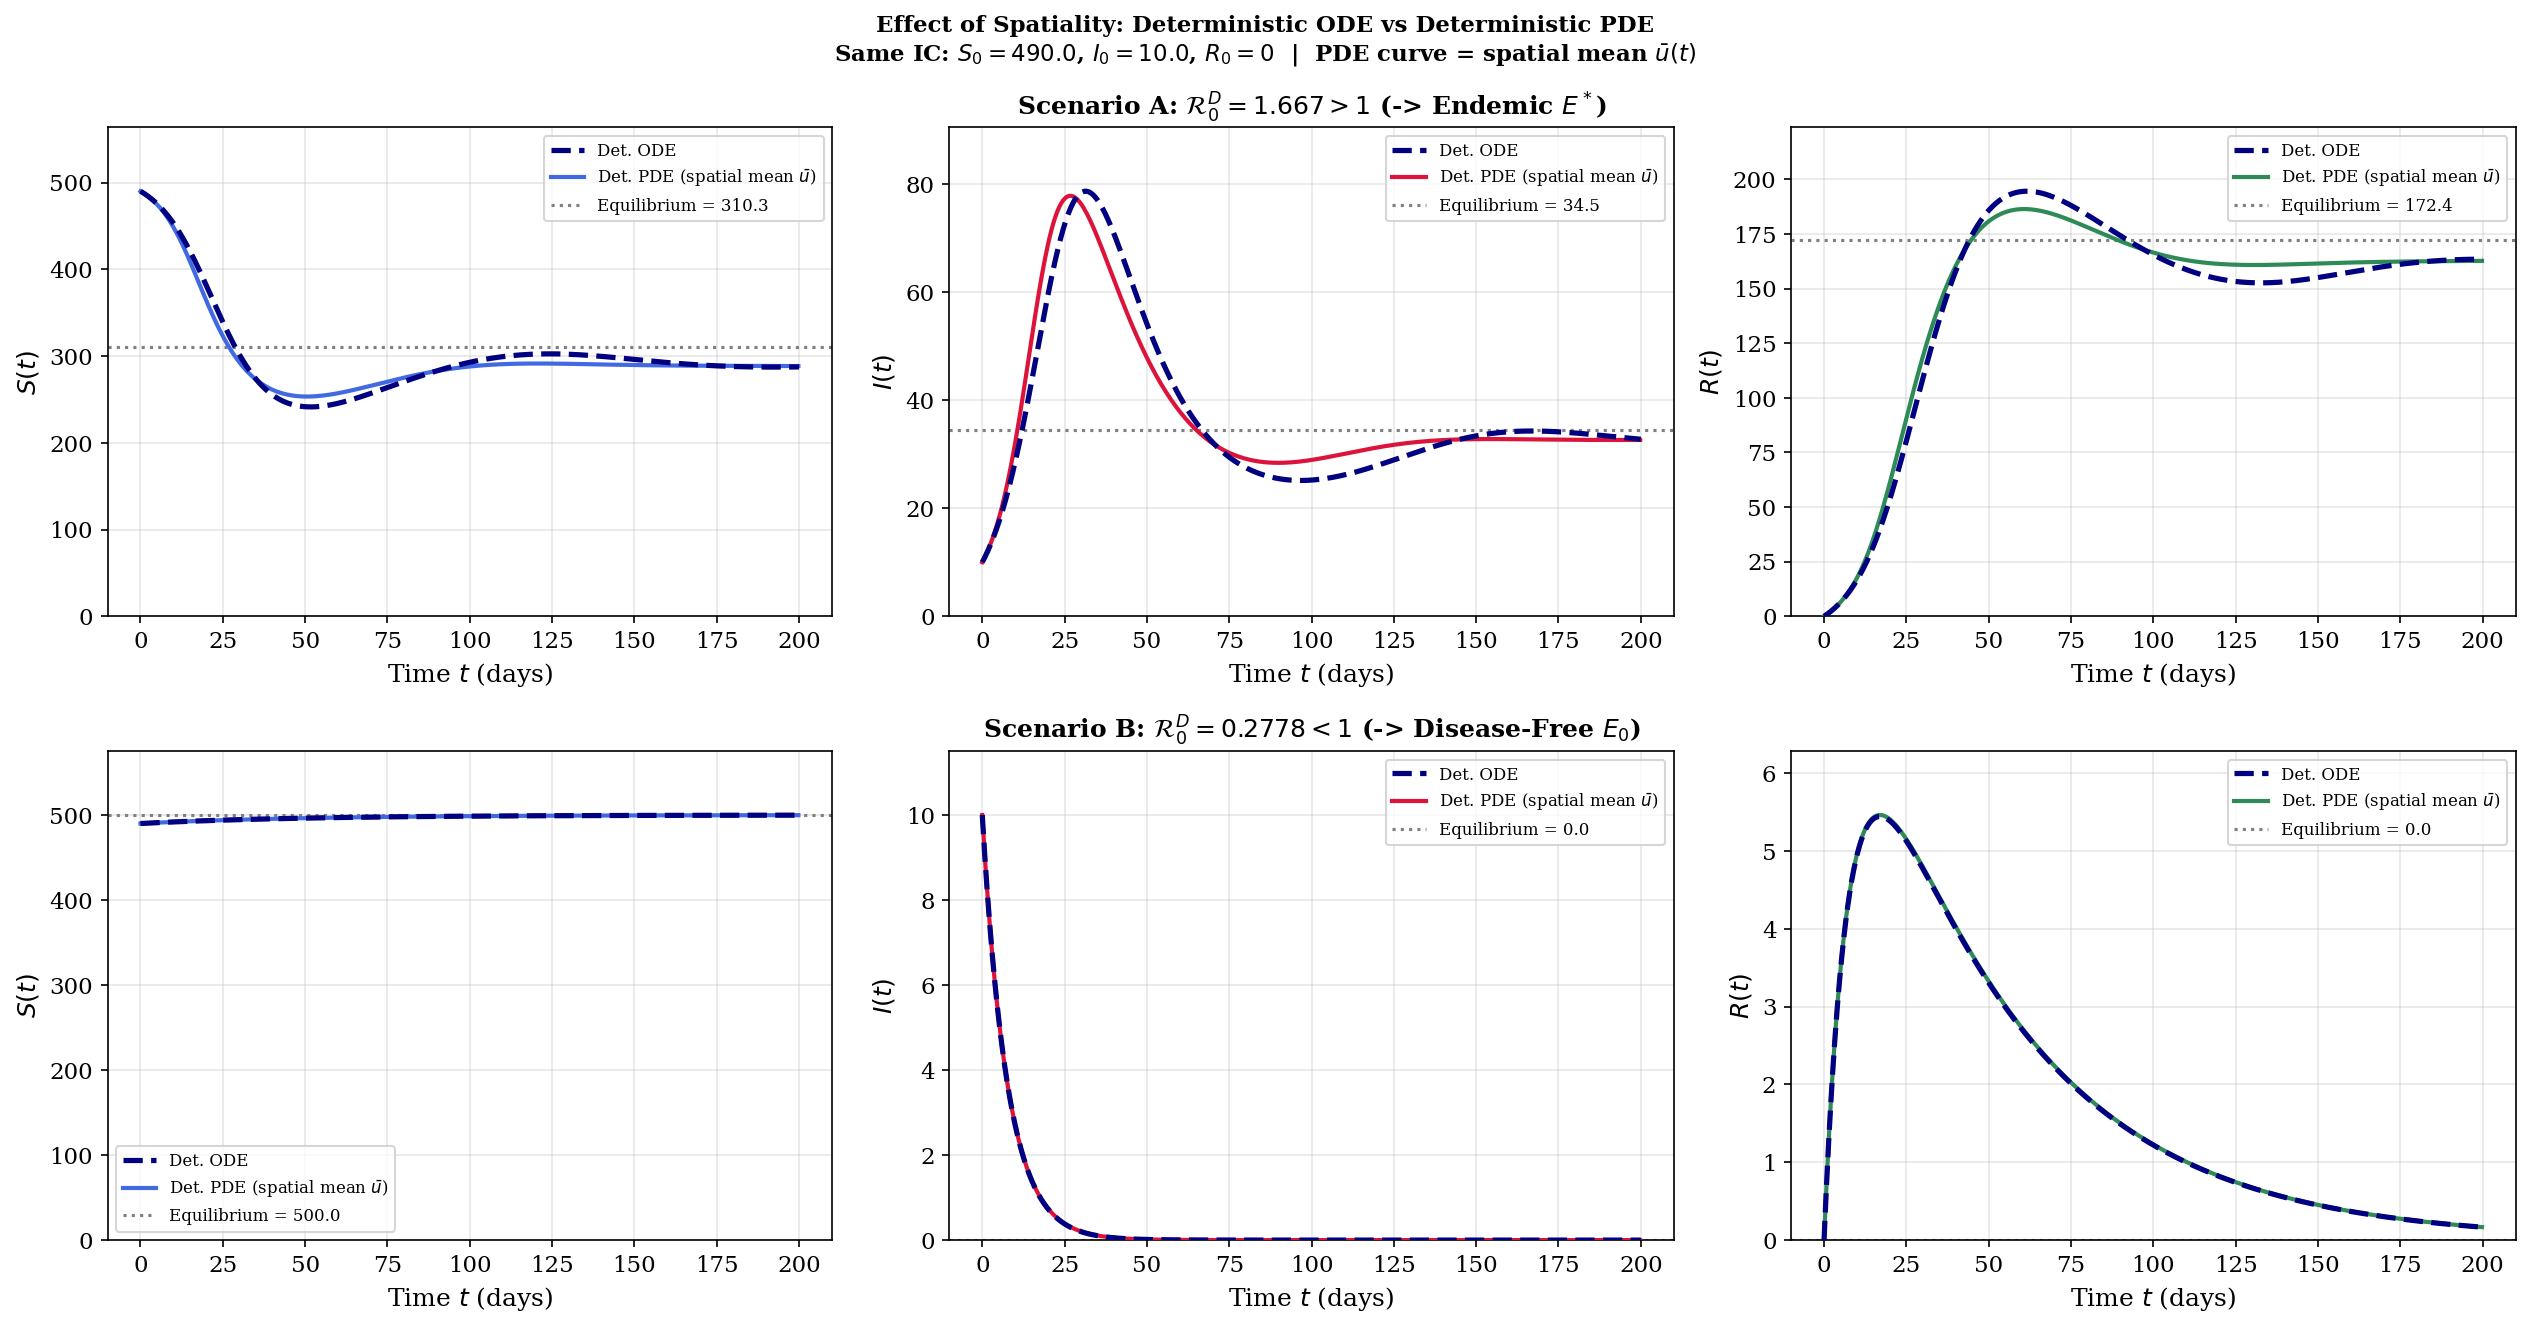

Fig 4 OK - dt_pde=0.040812 for both scenarios


In [10]:
# ODE solutions over T_pde for comparison
t_oA_p, S_oA_p, I_oA_p, R_oA_p = solve_sir(S0_val, I0_val, 0, params=_pA, t_end=T_pde, n=4001)
t_oB_p, S_oB_p, I_oB_p, R_oB_p = solve_sir(S0_val, I0_val, 0, params=_pB, t_end=T_pde, n=4001)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle(
    "Effect of Spatiality: Deterministic ODE vs Deterministic PDE\n"
    f"Same IC: $S_0={S0_val}$, $I_0={I0_val}$, $R_0=0$  |  "
    r"PDE curve = spatial mean $\bar{u}(t)$",
    fontsize=11, fontweight='bold')

for row, (t_ode_, S_o, I_o, R_o, t_pde_, S_p, I_p, R_p, eq_vals, scen_title) in enumerate([
    (t_oA_p, S_oA_p, I_oA_p, R_oA_p, t_pA, S_pA, I_pA, R_pA,
     [S_star, I_star, R_star],
     fr"Scenario A: $\mathcal{{R}}_0^D={R0_D:.3f}>1$ (Convergence to Endemic $E^*$)"),
    (t_oB_p, S_oB_p, I_oB_p, R_oB_p, t_pB, S_pB, I_pB, R_pB,
     [S0_dfe, 0.0, 0.0],
     fr"Scenario B: $\mathcal{{R}}_0^D={R0_B:.4f}<1$ (Convergence to Disease-Free $E_0$)"),
]):
    for col, (So, Sp, lbl, col_, ev) in enumerate(zip(
            [S_o, I_o, R_o], [S_p, I_p, R_p],
            [r'$S(t)$', r'$I(t)$', r'$R(t)$'],
            ['royalblue','crimson','seagreen'],
            eq_vals)):
        ax = axes[row, col]
        ax.plot(t_ode_, So, 'navy', lw=2.5, ls='--', label='Det. ODE', zorder=4)
        ax.plot(t_pde_, Sp.mean(axis=1), color=col_, lw=2.0,
                label=r'Det. PDE (spatial mean $\bar{u}$)', zorder=3)
        ax.axhline(ev, color='gray', ls=':', lw=1.5, label=f'Equilibrium = {ev:.1f}')
        ax.set_xlabel('Time $t$ (days)'); ax.set_ylabel(lbl)
        y_top = max(So.max(), Sp.mean(axis=1).max(), ev) * 1.15
        ax.set_ylim(0, max(y_top, 1.0))
        ax.legend(fontsize=8)
        if col == 1: ax.set_title(scen_title, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_ODE_vs_PDE.png', bbox_inches='tight')
plt.show()
print("  ")
print(f"dt_pde={dt_pde:.6f} for both scenarios")

## c) Deterministic ODE vs Stochastic SDE

Here I consider the initial same conditions as previously.

Euler–Maruyama with $dt_s=0.0005$.  
Noise: $\sigma_A=0.05$ ($\mathcal{R}_0^S>1$, persistence) and $\sigma_B=0.60$ ($\mathcal{R}_0^S<1$, extinction).


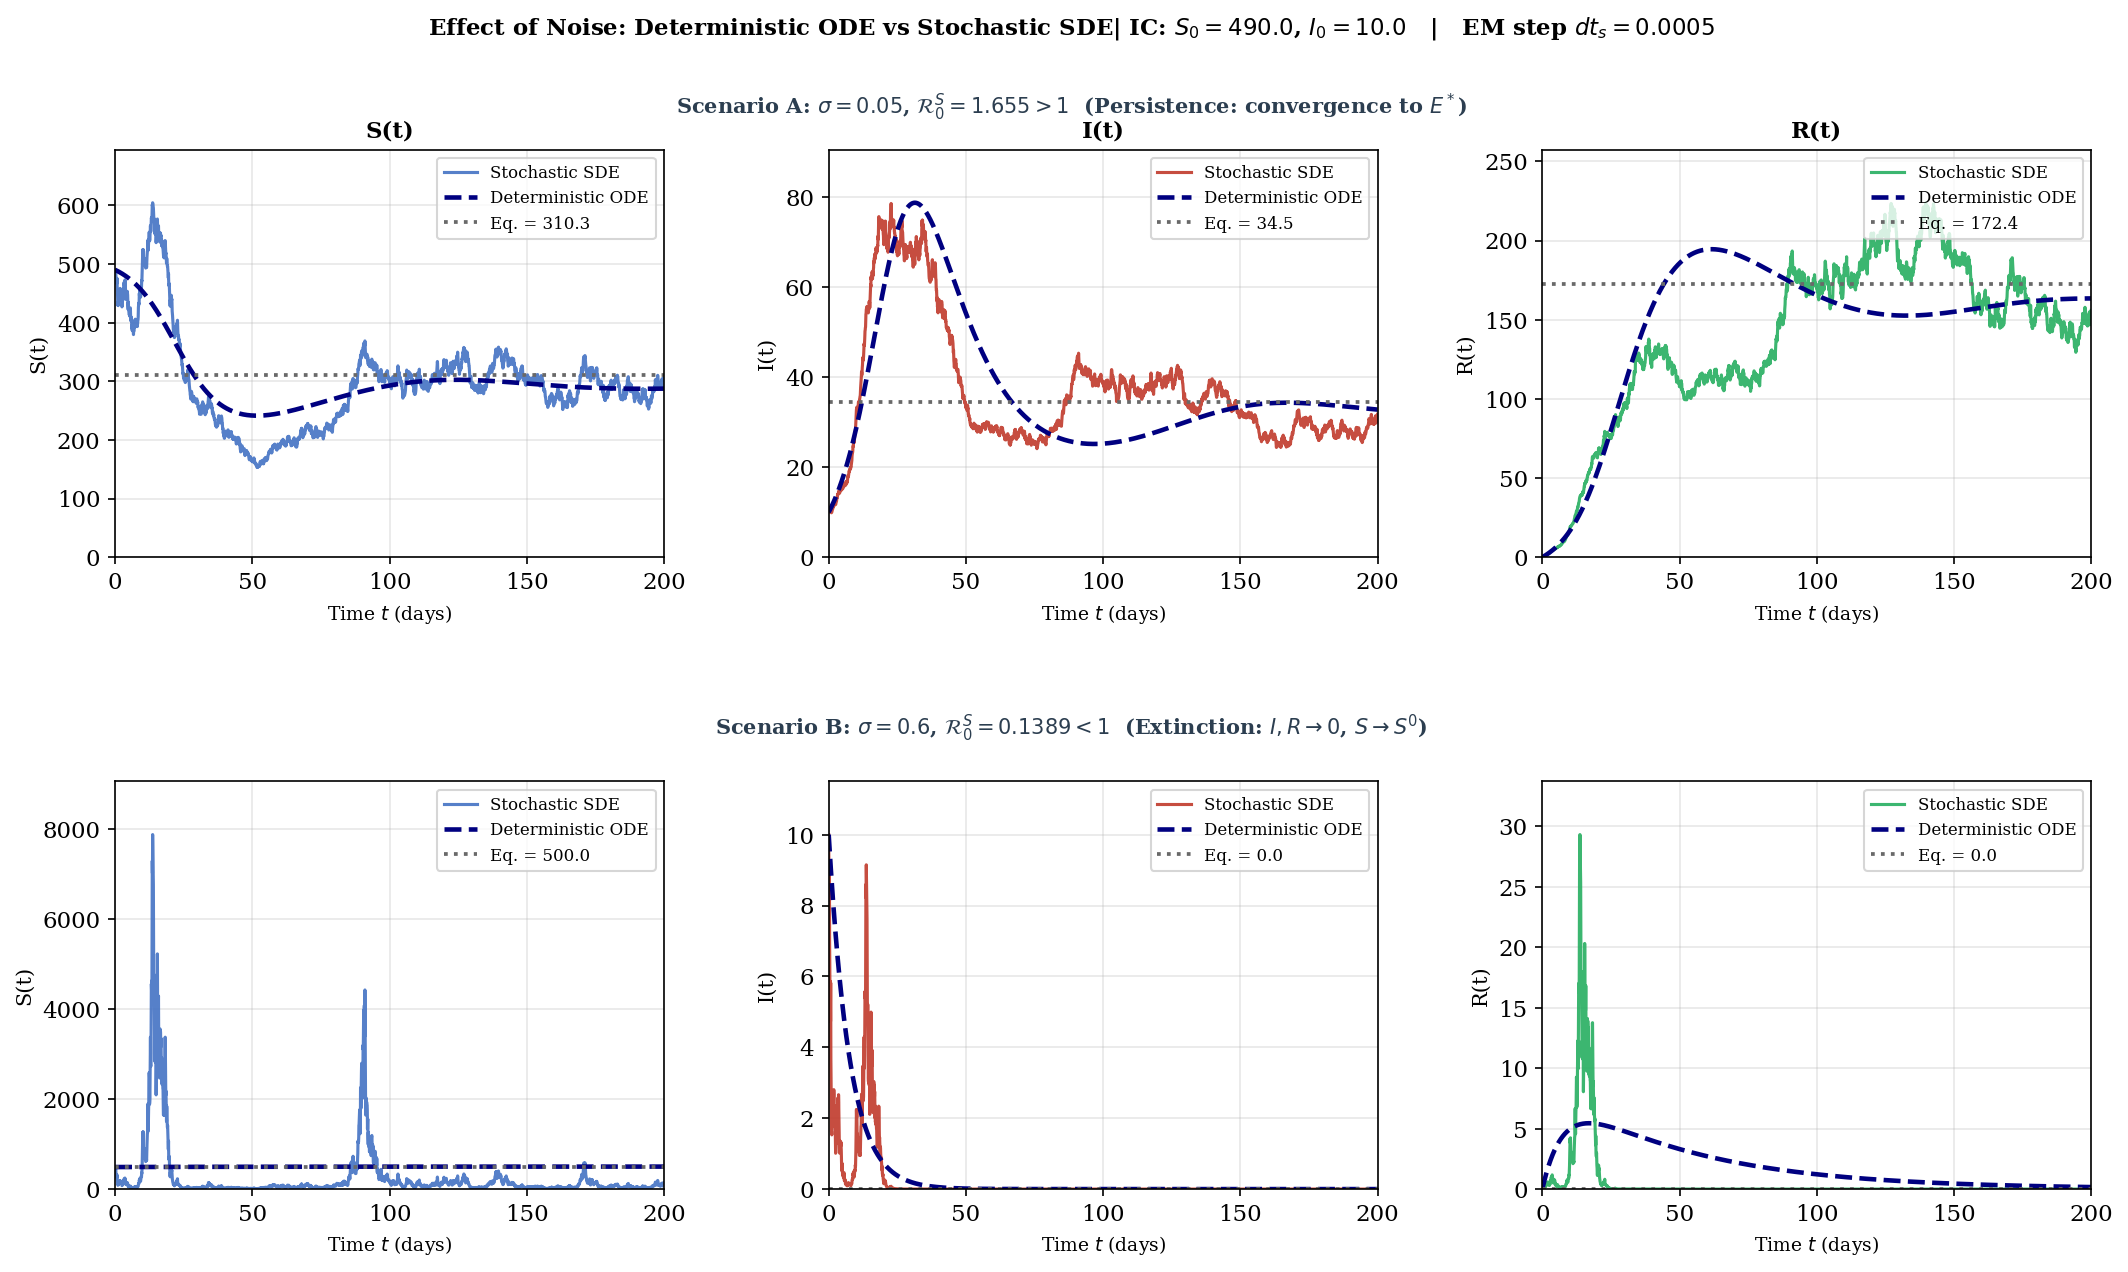

  
dt_s=0.0005


In [33]:
# ODE over T_sde
t_oA_s, S_oA_s, I_oA_s, R_oA_s = solve_sir(S0_val, I0_val, 0, params=_pA, t_end=T_sde, n=4001)
t_oB_s, S_oB_s, I_oB_s, R_oB_s = solve_sir(S0_val, I0_val, 0, params=_pB, t_end=T_sde, n=4001)

R0S_B_sde = beta_B / (m_p + sigma_B**2/2)

fig, axes = plt.subplots(2, 3, figsize=(17, 9),
                         gridspec_kw={'hspace': 0.55, 'wspace': 0.30})

fig.text(0.5, 0.98,
         f"Effect of Noise: Deterministic ODE vs Stochastic SDE"
         f" | IC: $S_0={S0_val}$, $I_0={I0_val}$ | EM step $dt_s={dt_s}$",
         ha='center', va='top', fontsize=11, fontweight='bold', color='black')

row_titles = [
    fr"Scenario A: $\sigma={sigma_A}$, $\mathcal{{R}}_0^S={R0S_A:.3f}>1$  (Persistence: convergence to $E^*$)",
    fr"Scenario B: $\sigma={sigma_B}$, $\mathcal{{R}}_0^S={R0S_B_sde:.4f}<1$  (Extinction: $I,R\to0$, $S\to S^0$)",
]

row_y = [0.90, 0.44]

for row, (t_s, S_s, I_s, R_s, t_d, S_d, I_d, R_d, eq_vals) in enumerate([
        (t_sA, S_sA, I_sA, R_sA, t_oA_s, S_oA_s, I_oA_s, R_oA_s,
         [S_star, I_star, R_star]),
        (t_sB, S_sB, I_sB, R_sB, t_oB_s, S_oB_s, I_oB_s, R_oB_s,
         [S0_dfe, 0.0, 0.0]),
]):
    fig.text(0.5, row_y[row], row_titles[row],
             ha='center', va='bottom', fontsize=10,
             fontweight='bold', color='#2C3E50')

    for col, (stoch, det, lbl, col_, ev) in enumerate(zip(
            [S_s, I_s, R_s], [S_d, I_d, R_d],
            ['S(t)', 'I(t)', 'R(t)'],
            ['#4472C4', '#C0392B', '#27AE60'],
            eq_vals)):
        ax = axes[row, col]
        ax.plot(t_s, np.maximum(stoch, 0), color=col_, lw=1.5, alpha=0.9, label='Stochastic SDE')
        ax.plot(t_d, np.maximum(det,   0), 'navy', lw=2.2, ls='--', label='Deterministic ODE')
        ax.axhline(ev, color='dimgray', ls=':', lw=1.8, label=f'Eq. = {ev:.1f}')
        y_top = max(np.maximum(stoch, 0).max(), np.maximum(det, 0).max(), ev) * 1.15
        ax.set_ylim(0, max(y_top, 1.0))
        ax.set_xlim(0, T_sde)
        ax.set_xlabel('Time $t$ (days)', fontsize=9)
        ax.set_ylabel(lbl, fontsize=10)
        if row == 0:
            ax.set_title(lbl, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8, loc='upper right')

plt.savefig('fig5_ODE_vs_SDE.png', bbox_inches='tight', dpi=150)
plt.show()
print("  ")
print(f"dt_s={dt_s}")

## d) Deterministic ODE vs Stochastic PDE (SPDE)

Same IC. SPDE spatial mean $\bar{u}(t)$ compared to ODE solution.  
Shaded band: 10th–90th percentile over 10 Monte-Carlo paths.


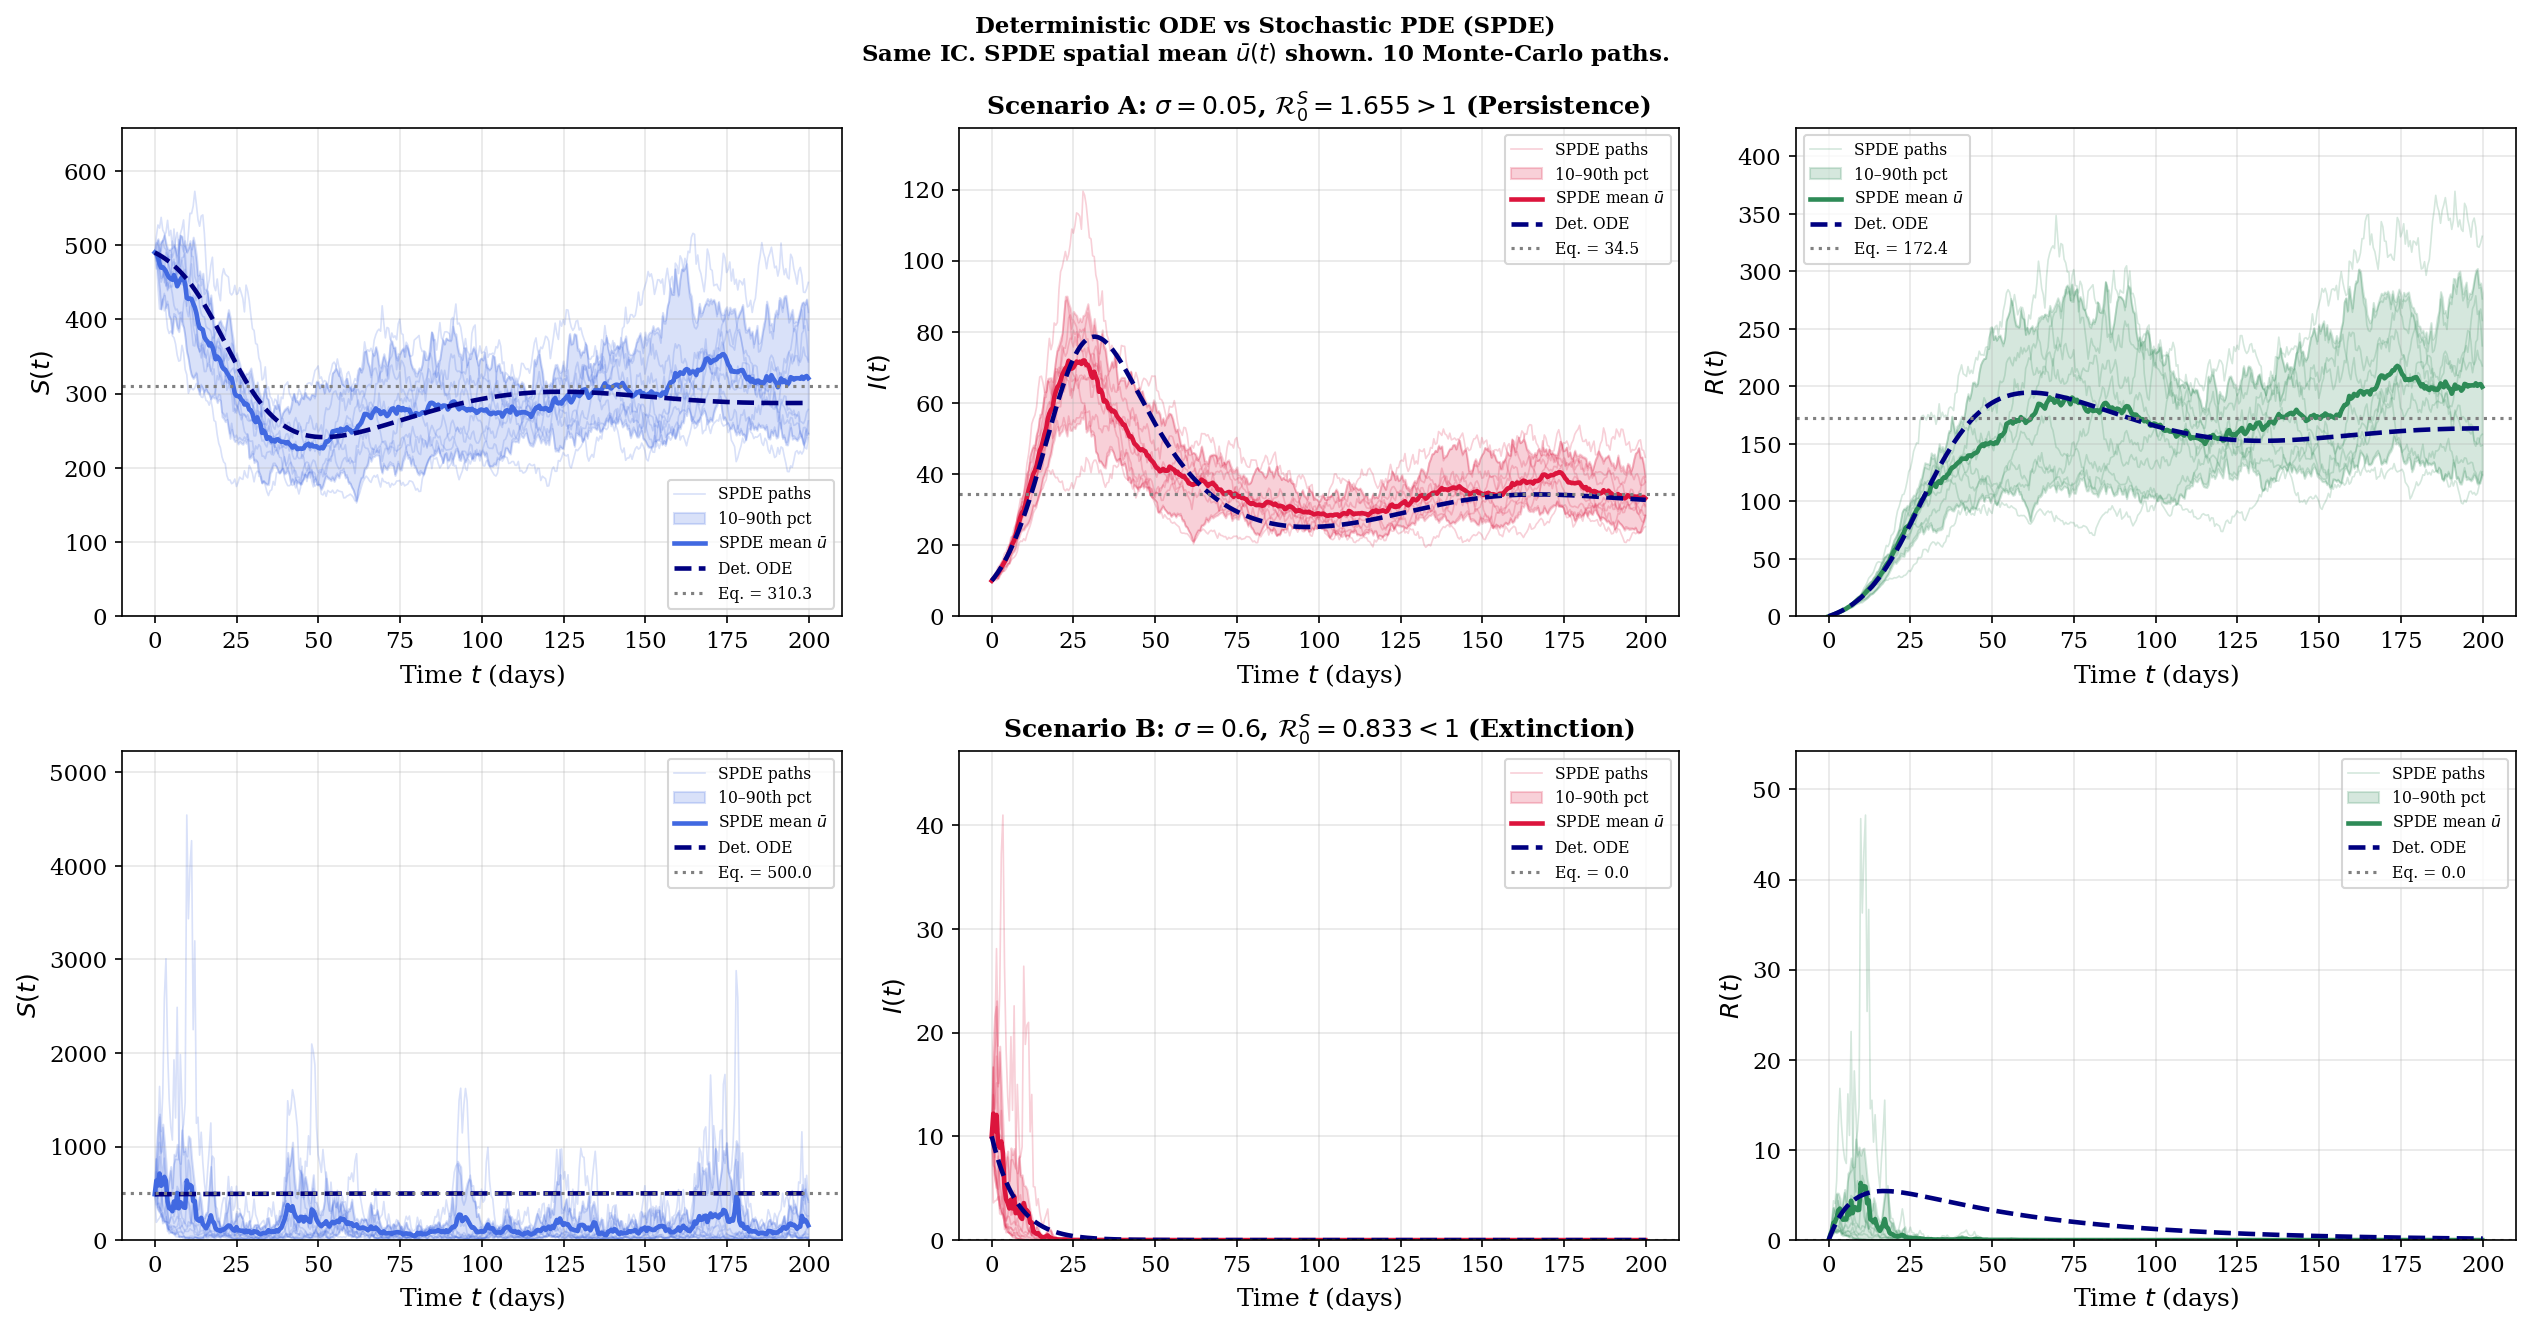

Fig 6 OK


In [12]:
# ODE over T_pde
t_oA_q, S_oA_q, I_oA_q, R_oA_q = solve_sir(S0_val, I0_val, 0, params=_pA, t_end=T_pde, n=4001)
t_oB_q, S_oB_q, I_oB_q, R_oB_q = solve_sir(S0_val, I0_val, 0, params=_pB, t_end=T_pde, n=4001)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle(
    "Deterministic ODE vs Stochastic PDE (SPDE)\n"
    fr"Same IC. SPDE spatial mean $\bar{{u}}(t)$ shown. {n_paths} Monte-Carlo paths.",
    fontsize=11, fontweight='bold')

for row, (t_ode_, S_o, I_o, R_o, paths, eq_vals, title) in enumerate([
    (t_oA_q, S_oA_q, I_oA_q, R_oA_q, spde_A,
     [S_star, I_star, R_star],
     fr"Scenario A: $\sigma={sigma_A}$, $\mathcal{{R}}_0^S={R0S_A:.3f}>1$ (Persistence)"),
    (t_oB_q, S_oB_q, I_oB_q, R_oB_q, spde_B,
     [S0_dfe, 0.0, 0.0],
     fr"Scenario B: $\sigma={sigma_B}$, $\mathcal{{R}}_0^S={R0S_B:.3f}<1$ (Extinction)"),
]):
    t_sp = paths[0][0]
    for col, (So, lbl, col_, ev, ci) in enumerate(zip(
            [S_o, I_o, R_o],
            [r'$S(t)$', r'$I(t)$', r'$R(t)$'],
            ['royalblue','crimson','seagreen'],
            eq_vals,
            [1, 2, 3])):
        sp = spde_smean(paths, ci)   # (n_paths, n_t)
        ax = axes[row, col]
        for k in range(n_paths):
            ax.plot(t_sp, sp[k], color=col_, alpha=0.20, lw=0.8,
                    label='SPDE paths' if k==0 else '')
        ax.fill_between(t_sp, np.percentile(sp,10,axis=0),
                        np.percentile(sp,90,axis=0),
                        color=col_, alpha=0.20, label='10–90th pct')
        ax.plot(t_sp, sp.mean(0), color=col_, lw=2.2,
                label=r'SPDE mean $\bar{u}$')
        ax.plot(t_ode_, So, 'navy', lw=2.2, ls='--', label='Det. ODE')
        ax.axhline(ev, color='gray', ls=':', lw=1.5, label=f'Eq. = {ev:.1f}')
        y_top = max(sp.max(), So.max(), ev) * 1.15
        ax.set_ylim(0, max(y_top, 1.0))
        ax.set_xlabel('Time $t$ (days)'); ax.set_ylabel(lbl)
        ax.legend(fontsize=7.5)
        if col == 1: ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_ODE_vs_SPDE.png', bbox_inches='tight')
plt.show()

## e) Deterministic PDE vs Stochastic PDE (SPDE)

Same IC, same spatial parameters, same $dt$. Both curves are spatial means.


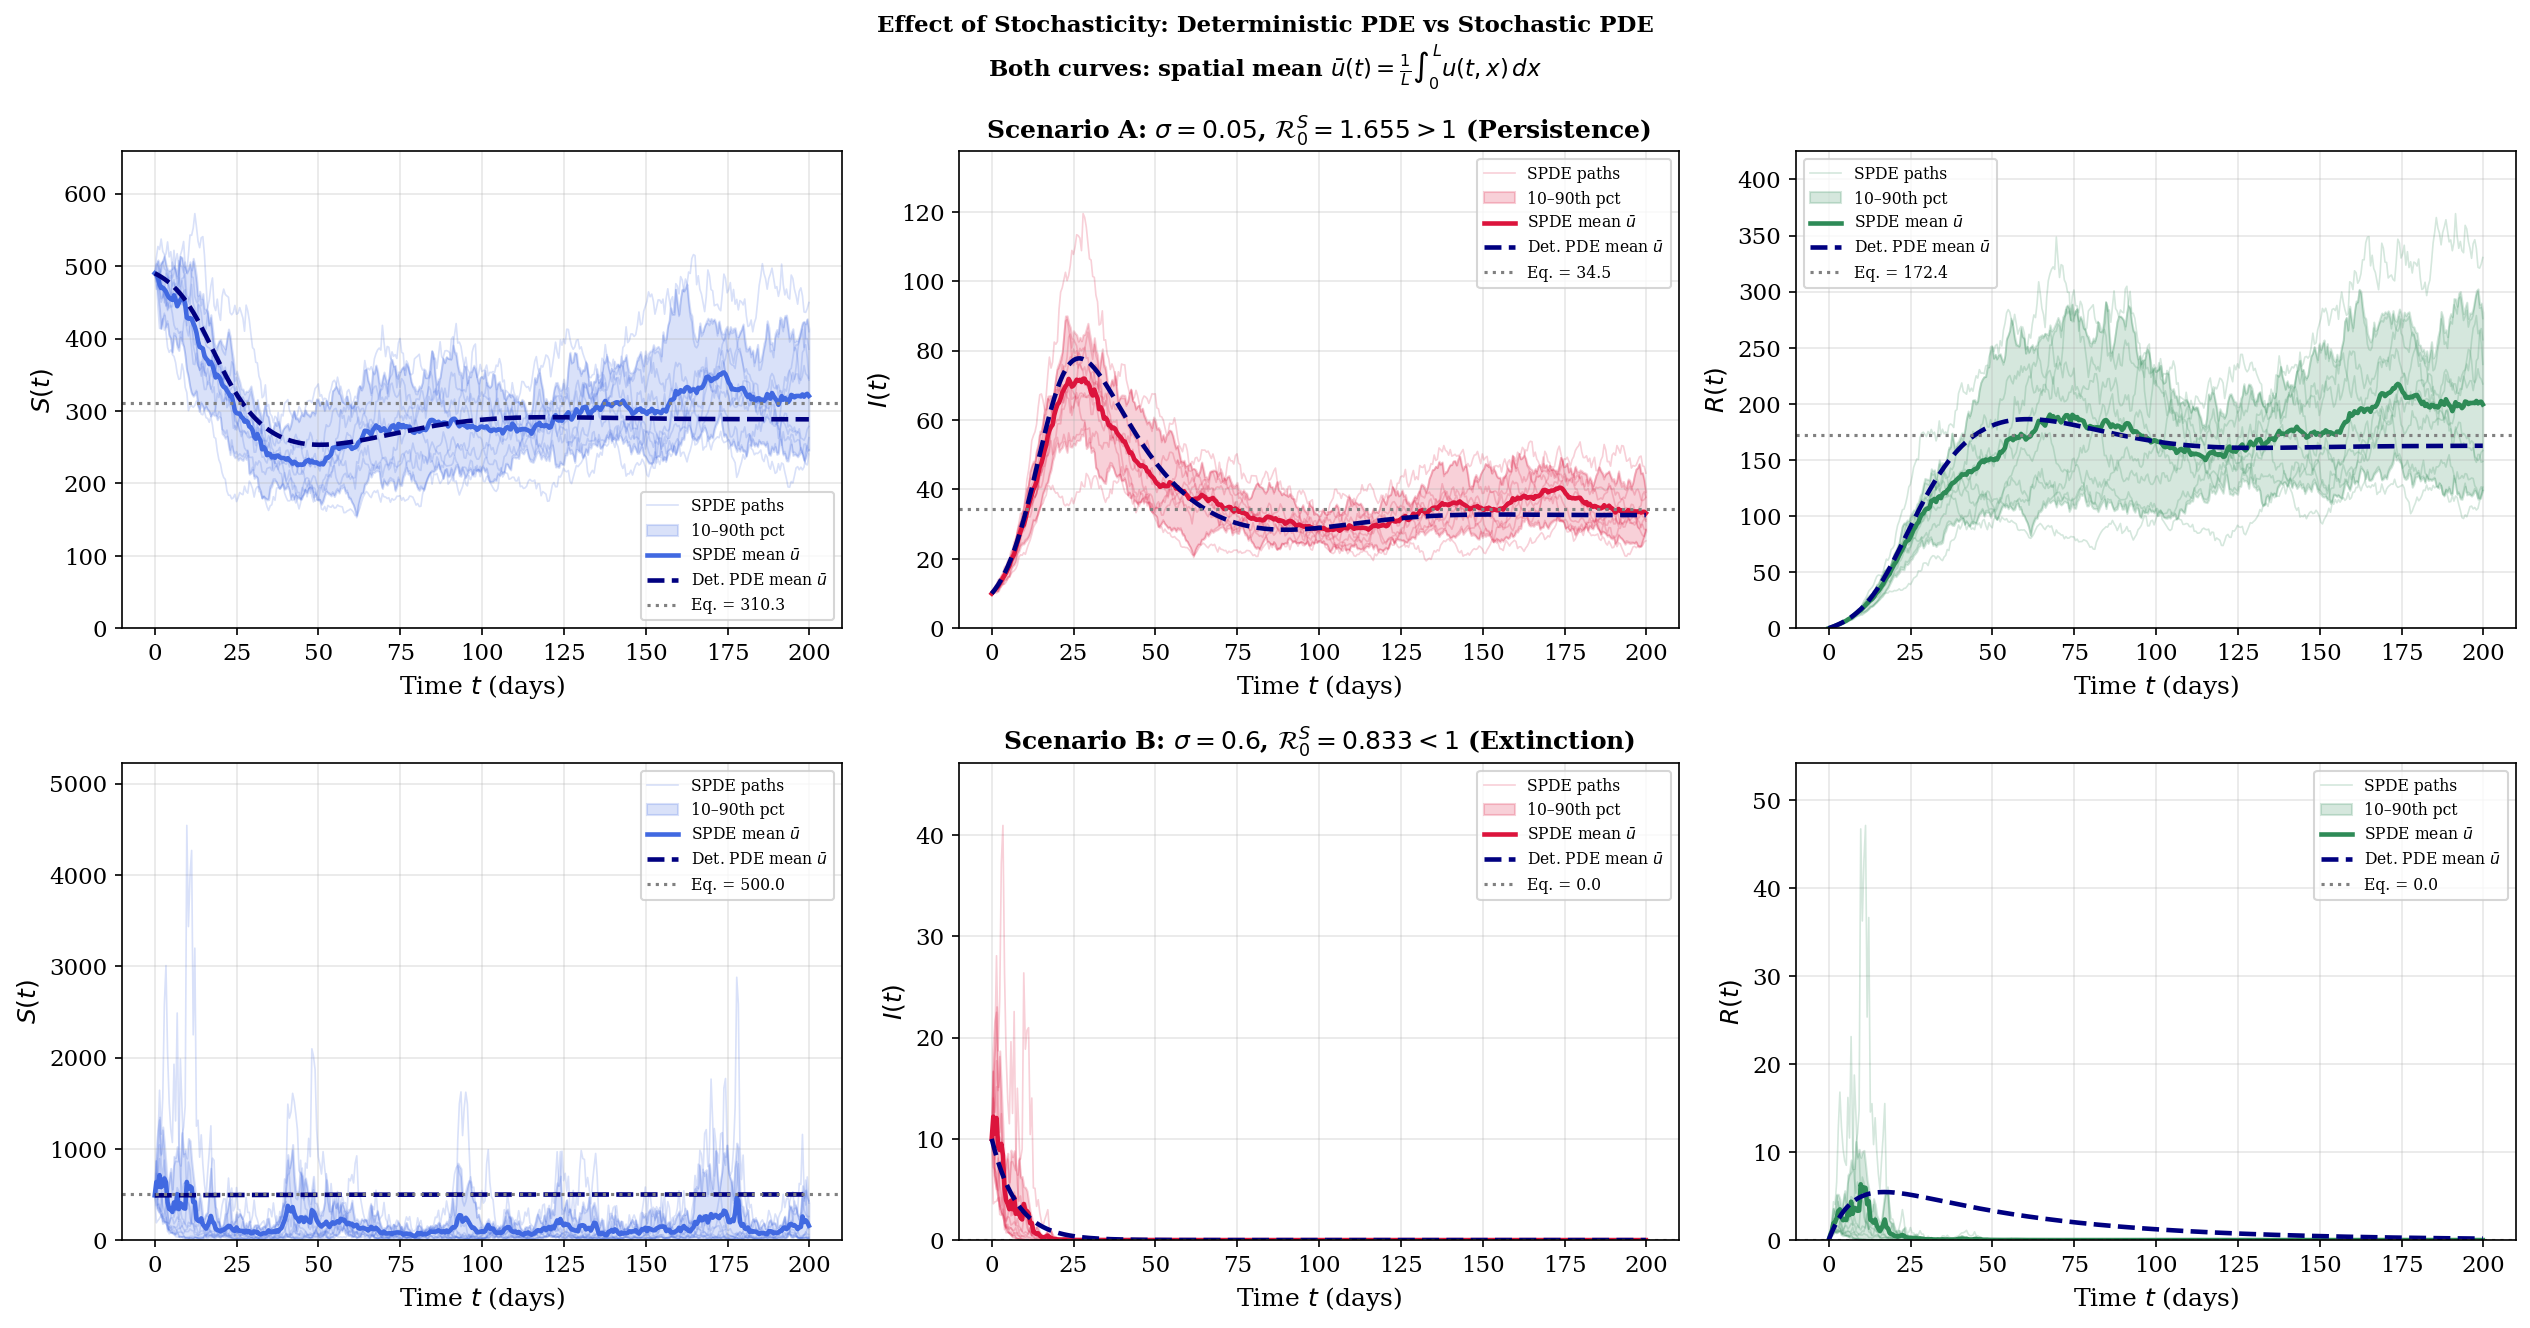

Fig 7 OK


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle(
    "Effect of Stochasticity: Deterministic PDE vs Stochastic PDE\n"
    r"Both curves: spatial mean $\bar{u}(t)=\frac{1}{L}\int_0^L u(t,x)\,dx$",
    fontsize=11, fontweight='bold')

for row, (t_pde_, Sp_d, Ip_d, Rp_d, paths, eq_vals, title) in enumerate([
    (t_pA, S_pA, I_pA, R_pA, spde_A,
     [S_star, I_star, R_star],
     fr"Scenario A: $\sigma={sigma_A}$, $\mathcal{{R}}_0^S={R0S_A:.3f}>1$ (Persistence)"),
    (t_pB, S_pB, I_pB, R_pB, spde_B,
     [S0_dfe, 0.0, 0.0],
     fr"Scenario B: $\sigma={sigma_B}$, $\mathcal{{R}}_0^S={R0S_B:.3f}<1$ (Extinction)"),
]):
    t_sp = paths[0][0]
    for col, (Pd, lbl, col_, ev, ci) in enumerate(zip(
            [Sp_d, Ip_d, Rp_d],
            [r'$S(t)$', r'$I(t)$', r'$R(t)$'],
            ['royalblue','crimson','seagreen'],
            eq_vals, [1,2,3])):
        sp = spde_smean(paths, ci)
        ax = axes[row, col]
        for k in range(n_paths):
            ax.plot(t_sp, sp[k], color=col_, alpha=0.20, lw=0.8,
                    label='SPDE paths' if k==0 else '')
        ax.fill_between(t_sp, np.percentile(sp,10,axis=0),
                        np.percentile(sp,90,axis=0),
                        color=col_, alpha=0.20, label='10–90th pct')
        ax.plot(t_sp, sp.mean(0), color=col_, lw=2.2,
                label=r'SPDE mean $\bar{u}$')
        ax.plot(t_pde_, Pd.mean(axis=1), 'navy', lw=2.2, ls='--',
                label=r'Det. PDE mean $\bar{u}$')
        ax.axhline(ev, color='gray', ls=':', lw=1.5, label=f'Eq. = {ev:.1f}')
        y_top = max(sp.max(), Pd.mean(axis=1).max(), ev) * 1.15
        ax.set_ylim(0, max(y_top, 1.0))
        ax.set_xlabel('Time $t$ (days)'); ax.set_ylabel(lbl)
        ax.legend(fontsize=7.5)
        if col == 1: ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('fig7_PDE_vs_SPDE.png', bbox_inches='tight')
plt.show()

## f) Spatial Profiles and Space-Time Heatmaps of $I(t,x)$ (SPDE, one path)

These figures show the **full spatial field** $I(t,x)$ from a single representative SPDE path,  
illustrating how the infection spreads (Scenario A) or dies out (Scenario B) in space and time.


In [ ]:
path_A0 = spde_A[0]   # single representative path
path_B0 = spde_B[0]
t_hm  = path_A0[0]
I_hmA = path_A0[2]   # (n_snap, Nx)
I_hmB = path_B0[2]

T_max = t_hm[-1]
snap_times = [t for t in [0, 25, 50, 75, 100, 125, 150, 175, 200] if t <= T_max]
snap_idx   = [np.argmin(np.abs(t_hm - ts)) for ts in snap_times]
cols_s     = plt.cm.viridis(np.linspace(0.1, 0.9, len(snap_times)))

# Spatial profiles
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(r"Spatial Profiles of $I(t,x)$ - SPDE, single path, temporal noise $B(t)$",
             fontsize=12, fontweight='bold')

for ax, I_hm, title in zip(axes, [I_hmA, I_hmB], [
        fr"Scenario A: $\sigma={sigma_A}$, $\mathcal{{R}}_0^S={R0S_A:.3f}>1$",
        fr"Scenario B: $\sigma={sigma_B}$, $\mathcal{{R}}_0^S={R0S_B:.3f}<1$"]):
    for idx, t_lab, col in zip(snap_idx, snap_times, cols_s):
        ax.plot(x, I_hm[idx], color=col, lw=1.5, label=f't={t_lab}')
    ax.set_xlabel('Space $x$'); ax.set_ylabel('$I(t,x)$')
    ax.set_ylim(bottom=0)
    ax.set_title(title)
    ax.legend(title='Time (days)', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('fig8_spatial_profiles.png', bbox_inches='tight')
plt.show()

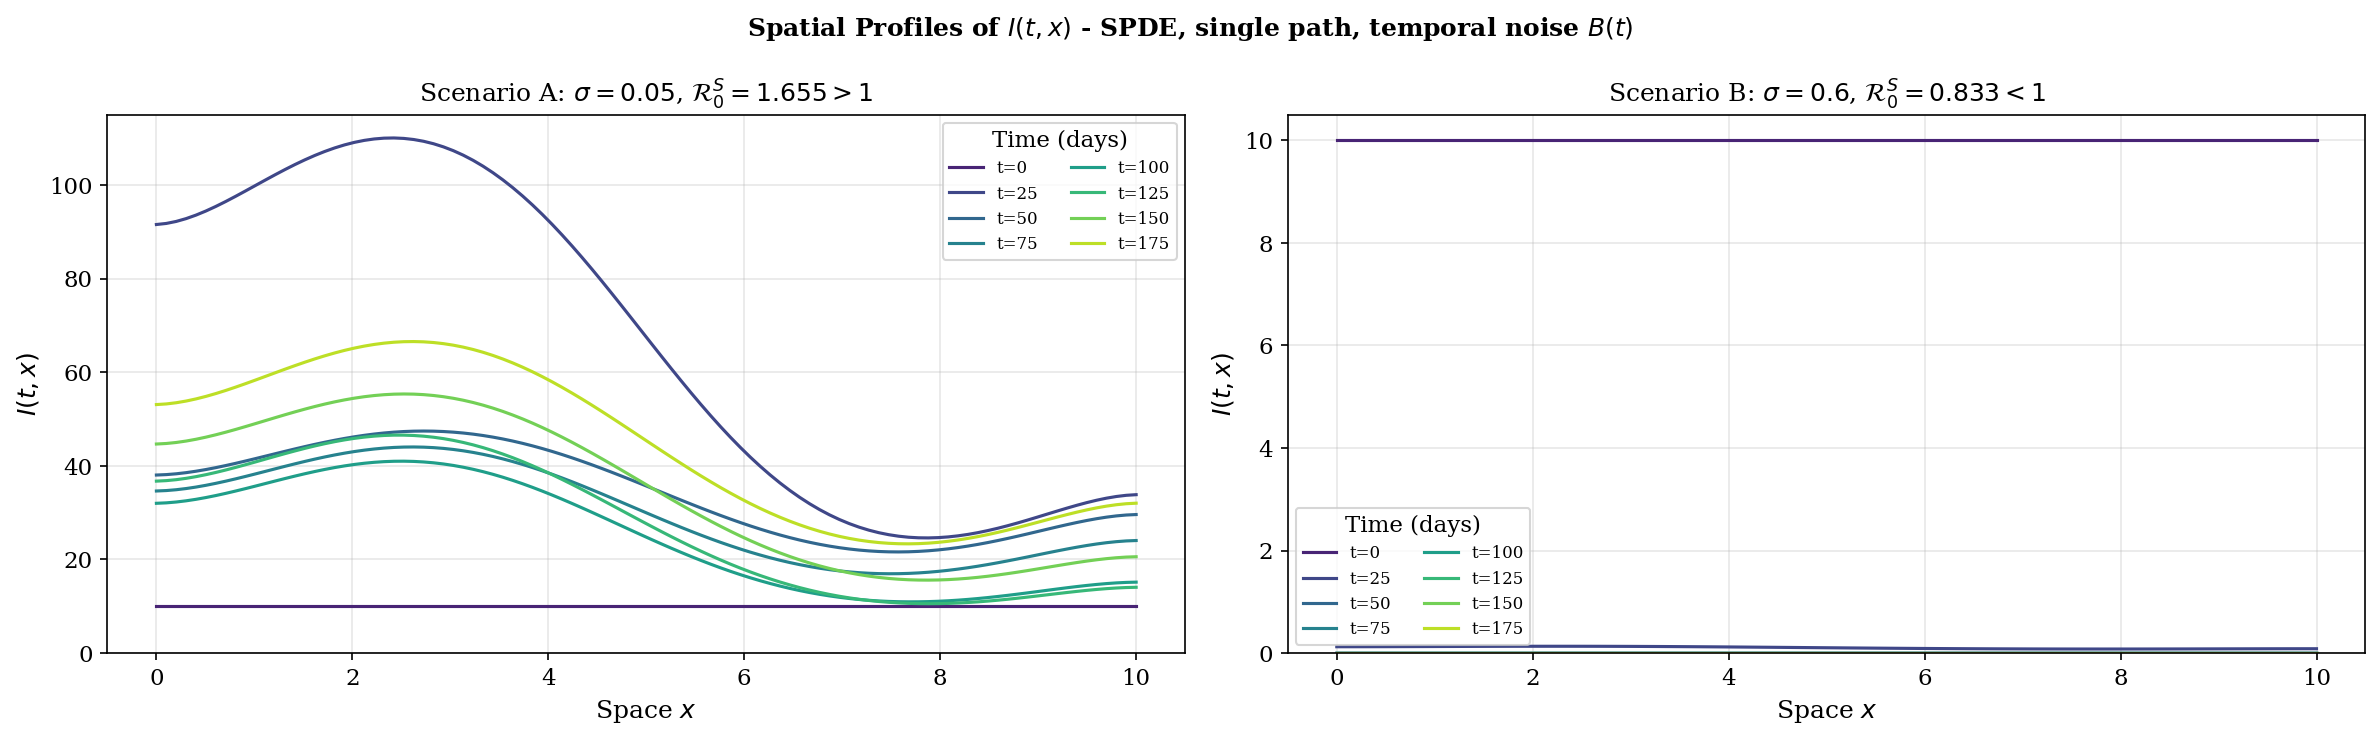

Fig 8 OK


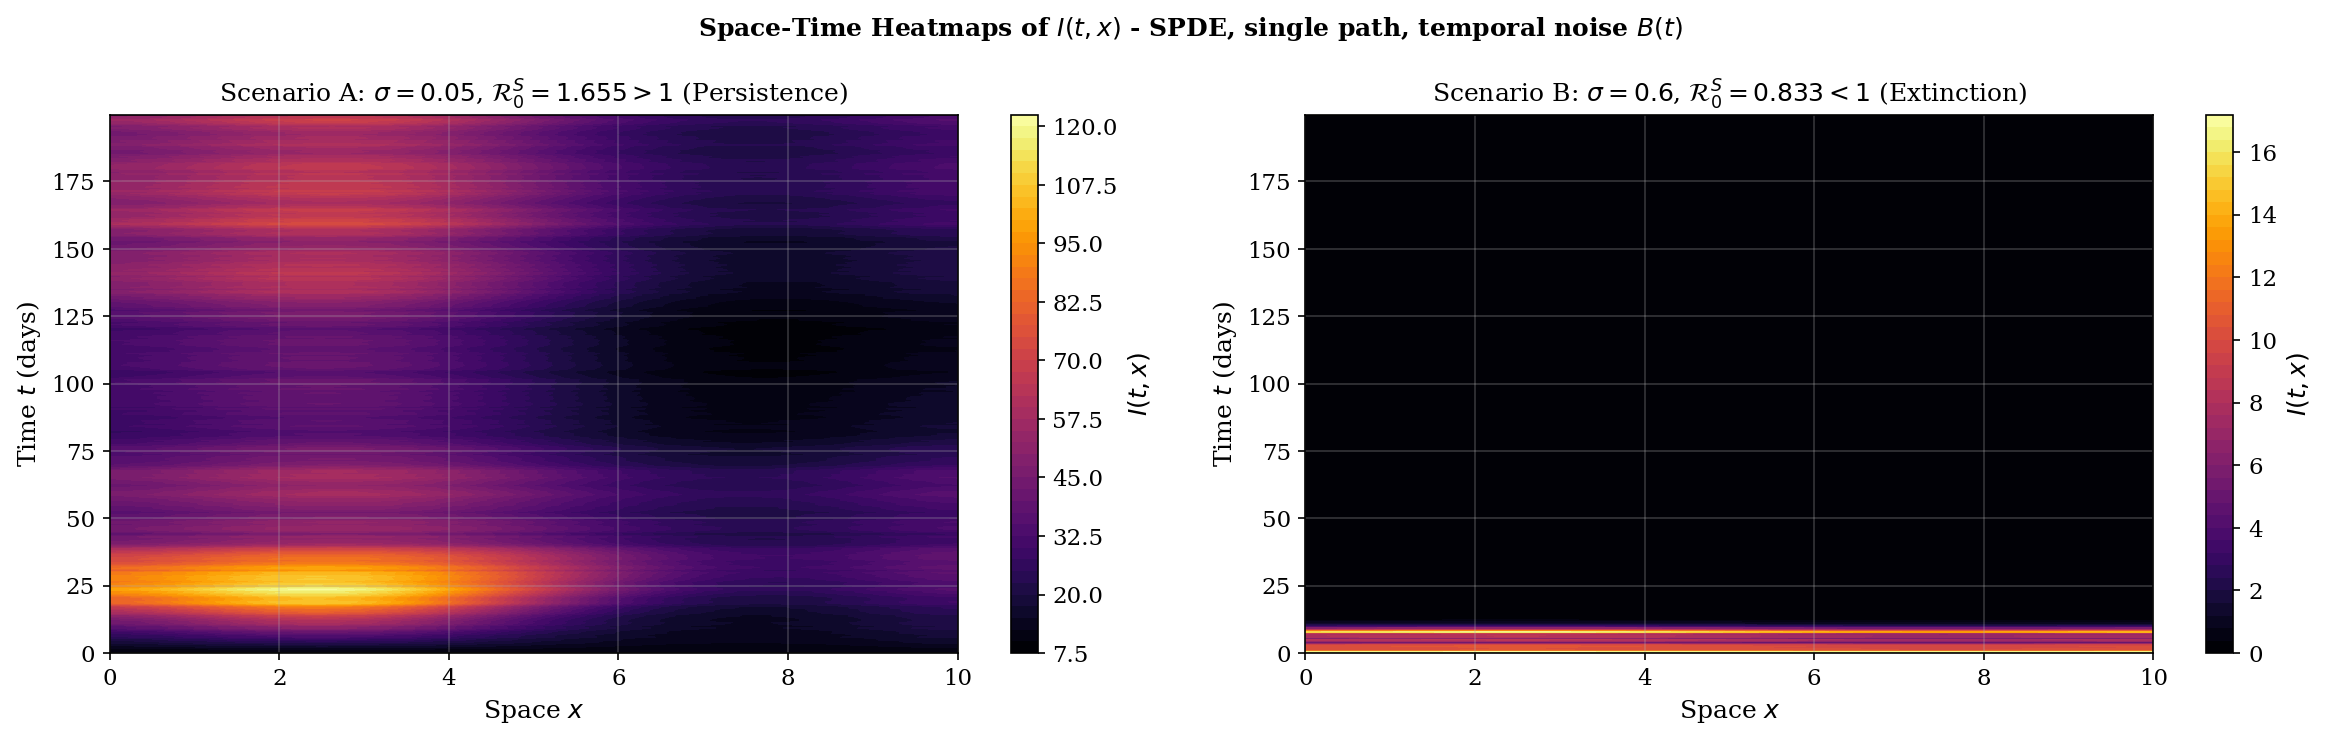

Fig 9 OK


In [ ]:
# Space-time heatmaps 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(r"Space-Time Heatmaps of $I(t,x)$ - SPDE, single path, temporal noise $B(t)$",
             fontsize=12, fontweight='bold')

for ax, I_hm, title in zip(axes, [I_hmA, I_hmB], [
        fr"Scenario A: $\sigma={sigma_A}$, $\mathcal{{R}}_0^S={R0S_A:.3f}>1$ (Persistence)",
        fr"Scenario B: $\sigma={sigma_B}$, $\mathcal{{R}}_0^S={R0S_B:.3f}<1$ (Extinction)"]):
    cf = ax.contourf(x, t_hm, I_hm, levels=50, cmap='inferno')
    plt.colorbar(cf, ax=ax, label='$I(t,x)$')
    ax.set_xlabel('Space $x$'); ax.set_ylabel('Time $t$ (days)')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('fig9_heatmaps.png', bbox_inches='tight')
plt.show()

## g) Stochastic Bifurcation: $\mathcal{R}_0^S$ as a Function of Noise Intensity $\sigma$

The critical noise level $\sigma^*$ satisfying $\mathcal{R}_0^S=1$ is:
$$\sigma^* = \sqrt{2(\beta - m)} \quad (\text{if } \beta > m).$$


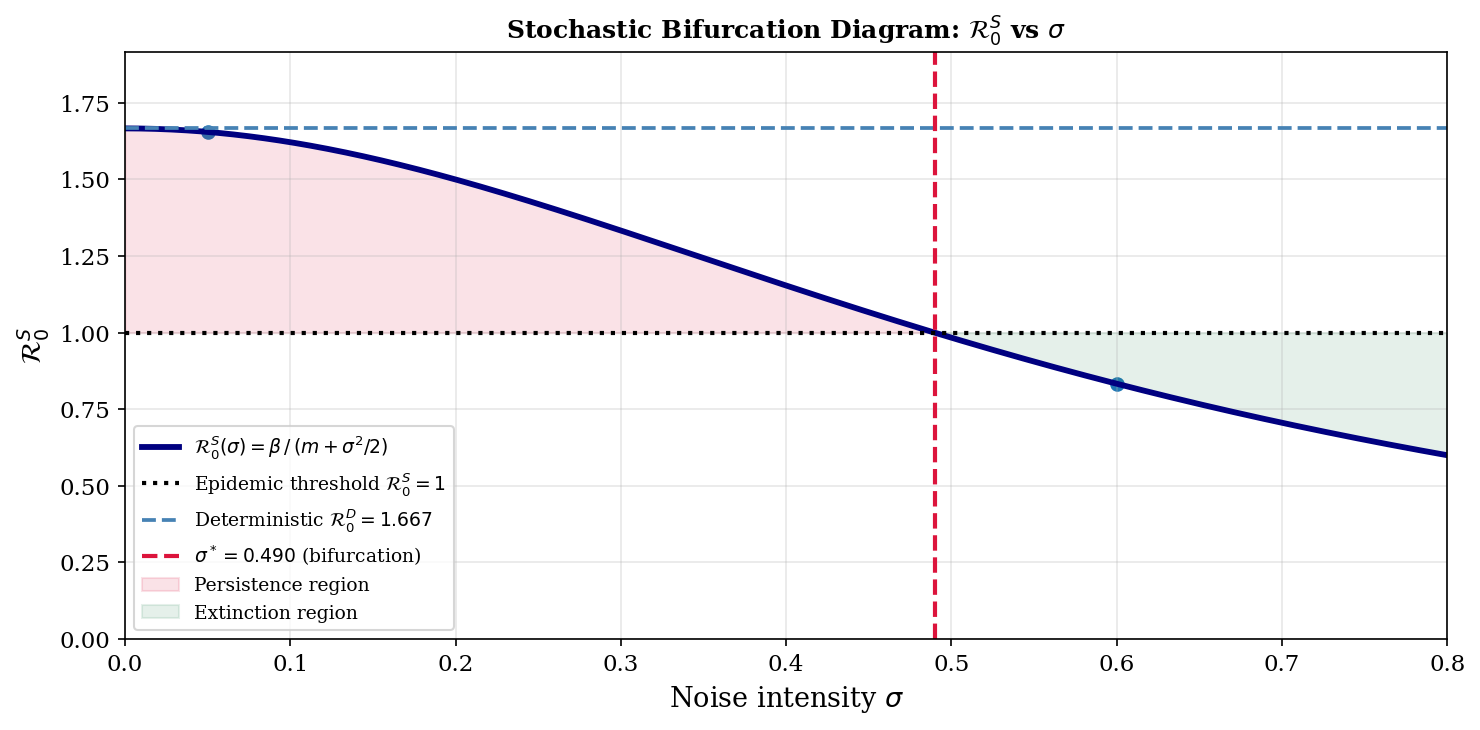

sigma* = 0.4899


In [17]:
sigma_range = np.linspace(0, 0.8, 600)
R0S_range   = beta_p / (m_p + sigma_range**2 / 2)
sigma_star  = np.sqrt(max(2*(beta_p - m_p), 0.0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sigma_range, R0S_range, 'navy', lw=2.8,
        label=r'$\mathcal{R}_0^S(\sigma) = \beta\,/\,(m+\sigma^2/2)$')
ax.axhline(1.0, color='black', ls=':', lw=2.0,
           label=r'Epidemic threshold $\mathcal{R}_0^S=1$')
ax.axhline(R0_D, color='steelblue', ls='--', lw=1.8,
           label=fr'Deterministic $\mathcal{{R}}_0^D={R0_D:.3f}$')
if sigma_star > 0:
    ax.axvline(sigma_star, color='crimson', ls='--', lw=2.0,
               label=fr'$\sigma^*={sigma_star:.3f}$ (bifurcation)')
ax.scatter([sigma_A, sigma_B],
           [beta_p/(m_p+sigma_A**2/2), beta_p/(m_p+sigma_B**2/2)],
           #color=['darkorange','seagreen'], s=120, zorder=5,
          )
ax.fill_between(sigma_range, R0S_range, 1.0,
                where=R0S_range>1, alpha=0.12, color='crimson', label='Persistence region')
ax.fill_between(sigma_range, R0S_range, 1.0,
                where=R0S_range<1, alpha=0.12, color='seagreen', label='Extinction region')
ax.set_xlabel(r'Noise intensity $\sigma$', fontsize=13)
ax.set_ylabel(r'$\mathcal{R}_0^S$', fontsize=13)
ax.set_title(r'Stochastic Bifurcation Diagram: $\mathcal{R}_0^S$ vs $\sigma$', fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim(0, 0.8); ax.set_ylim(0, R0_D*1.15)
plt.tight_layout()
plt.savefig('fig10_bifurcation.png', bbox_inches='tight')
plt.show()
print(f"sigma* = {sigma_star:.4f}")
